## Functions

In [1]:
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
 
WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"
 
 
# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------
 
def fetch_sweep_runs(sweep_name: str) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs
 
 
def compute_epoch_df(
    sweep_name: str,
    loss_metric: str,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
) -> pd.DataFrame:
    """
    Fetches all runs and returns a raw epoch-level DataFrame.
    One row per (x_val, run_val, seed_val, epoch).
 
    The optimality gap is computed as:
        opt_gap = loss[epoch] - floor(x_val, run_val)
    where floor = min loss across all seeds and epochs for that (x_val, run_val).
 
    Parameters
    ----------
    sweep_name    : W&B sweep ID
    loss_metric   : metric used to compute the optimality gap (also stored as a column)
    value_metrics : metrics to fetch and store as columns
    x_key         : config key for the grouping dimension (e.g. "stores")
    run_key       : config key identifying a unique policy (e.g. "run_idx")
    seed_key      : config key identifying the seed (e.g. "a_seed")
 
    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, {run_key}, {seed_key}, epoch, {loss_metric}, opt_gap, *value_metrics
    Metrics that are missing for a given epoch are NaN.
    """
    runs = fetch_sweep_runs(sweep_name)
    all_keys = [loss_metric] + value_metrics
    identifier_keys = (x_key, run_key, seed_key)
 
    # --- Step 1: fetch histories ---
    run_data = {}
    for run in runs:
        cfg = run.config
        try:
            key = tuple(cfg[k] for k in identifier_keys)
        except KeyError as e:
            print(f"Skipping run {run.id}: missing config key {e}")
            continue
 
        history = run.history(keys=all_keys, pandas=True)
        if history.empty:
            continue
 
        available = [c for c in all_keys if c in history.columns]
        sub = history[available].dropna(subset=[loss_metric]).reset_index(drop=True)
        if sub.empty:
            continue
 
        run_data[key] = sub
 
    if not run_data:
        raise ValueError("No valid run data found.")
 
    print(f"Valid runs: {len(run_data)}")
 
    # --- Step 2: compute floor per (x_val, run_val) ---
    floor: dict[tuple, float] = defaultdict(lambda: np.inf)
    for (x_val, run_val, seed_val), sub in run_data.items():
        policy_key = (x_val, run_val)
        floor[policy_key] = min(floor[policy_key], float(sub[loss_metric].min()))
 
    # --- Step 3: build epoch-level rows ---
    records = []
    for (x_val, run_val, seed_val), sub in run_data.items():
        best    = floor[(x_val, run_val)]
        opt_gap = sub[loss_metric].values - best
 
        chunk = sub.copy()
        chunk.insert(0, x_key,    x_val)
        chunk.insert(1, run_key,  run_val)
        chunk.insert(2, seed_key, seed_val)
        chunk.insert(3, "epoch",  np.arange(len(chunk)))
        chunk["opt_gap"] = opt_gap
        records.append(chunk)
 
    result = pd.concat(records, ignore_index=True)
 
    # Reorder: identifiers first, then opt_gap, then metrics
    id_cols     = [x_key, run_key, seed_key, "epoch", loss_metric, "opt_gap"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    return result[id_cols + metric_cols]
 
 
# ---------------------------------------------------------------------------
# Derived metrics (epoch-level)
# ---------------------------------------------------------------------------
 
def add_derived_metrics(
    epoch_df: pd.DataFrame,
    derived: dict[str, callable],
) -> pd.DataFrame:
    """
    Adds derived metric columns to the epoch-level DataFrame.
    Each callable receives the DataFrame and returns a Series.
 
    Parameters
    ----------
    epoch_df : output of compute_epoch_df
    derived  : dict mapping new column name -> callable(df) -> pd.Series
 
    Example
    -------
    derived = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df["train/grad_norm/continuous/pathwise/true"]
            / df["train/grad_norm/continuous/cross_ppo/true"]
        ),
    }
 
    Returns
    -------
    epoch_df with new columns appended (original df is not mutated).
    """
    result = epoch_df.copy()
    for name, fn in derived.items():
        try:
            result[name] = fn(result)
        except Exception as e:
            print(f"Could not compute derived metric '{name}': {e}")
    return result
 
 
# ---------------------------------------------------------------------------
# Bucketing + aggregation
# ---------------------------------------------------------------------------
 
def compute_bucketed_metrics(
    epoch_df: pd.DataFrame,
    value_metrics: list[str],
    x_key: str = "stores",
    run_key: str = "run_idx",
    seed_key: str = "a_seed",
    bucket_metric: str = "opt_gap",
    bucket_width: float = 5.0,
) -> pd.DataFrame:
    """
    Aggregates epoch-level data into buckets using two-stage averaging:
      Stage 1: mean per (run_key, seed_key, bucket)  — equal epoch weight per run
      Stage 2: simple average across (run_key, seed_key) — equal run weight
 
    Parameters
    ----------
    epoch_df      : output of compute_epoch_df (optionally with derived columns added)
    value_metrics : columns to aggregate
    x_key         : grouping dimension column (e.g. "stores")
    run_key       : run identity column (e.g. "run_idx")
    seed_key      : seed identity column (e.g. "a_seed")
    bucket_metric : column to bucketize on (e.g. "opt_gap" or any value metric)
    bucket_width  : width of each bucket
 
    Returns
    -------
    Wide-format pd.DataFrame with columns:
        {x_key}, bucket_left, bucket_right, {metric_1}, {metric_2}, ...
    One row per (x_val, bucket). Missing metric/bucket combos are NaN.
    """
    df = epoch_df.copy()
    df["bucket_left"] = (df[bucket_metric] // bucket_width) * bucket_width
 
    agg_records = []
    for x_val in df[x_key].unique():
        sub_x = df[df[x_key] == x_val]
 
        bucket_agg: dict[float, dict] = {}
        for metric in value_metrics:
            if metric not in sub_x.columns:
                continue
 
            rows = sub_x[[run_key, seed_key, "bucket_left", metric]].dropna(subset=[metric])
            if rows.empty:
                continue
 
            # Stage 1: mean per (run, seed, bucket)
            per_run = (
                rows.groupby([run_key, seed_key, "bucket_left"])[metric]
                .mean()
                .reset_index()
                .rename(columns={metric: "run_mean"})
            )
 
            # Stage 2: simple average across runs
            agg = (
                per_run.groupby("bucket_left")["run_mean"]
                .mean()
                .reset_index()
                .rename(columns={"run_mean": metric})
            )
 
            for _, row in agg.iterrows():
                bl = row["bucket_left"]
                if bl not in bucket_agg:
                    bucket_agg[bl] = {x_key: x_val, "bucket_left": bl,
                                      "bucket_right": bl + bucket_width}
                bucket_agg[bl][metric] = row[metric]
 
        agg_records.extend(bucket_agg.values())
 
    result = pd.DataFrame(agg_records)
    id_cols     = [x_key, "bucket_left", "bucket_right"]
    metric_cols = [c for c in result.columns if c not in id_cols]
    result = result[id_cols + metric_cols]
    result = result.sort_values([x_key, "bucket_left"]).reset_index(drop=True)
    return result
 
 
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------
 
def plot_metric_vs_x(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_value: float,
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    show_legend: bool = True,
    legend_names: list[str] | None = None,
    out_file: str | None = None,
) -> None:
    """
    Generic plot: x_key on x-axis, filter_key fixed to filter_value, one line per metric.
    Line labels use the last three slash-separated sections of the metric name by default.

    Typical usage A — x=stores, filter on gap bucket:
        plot_metric_vs_x(df, x_key="stores", filter_key="bucket_left", filter_value=0.0, ...)

    Typical usage B — x=gap bucket, filter on stores:
        plot_metric_vs_x(df, x_key="bucket_left", filter_key="stores", filter_value=10, ...)

    Parameters
    ----------
    df           : output of compute_bucketed_metrics
    x_key        : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key   : column to filter on (e.g. "bucket_left" or "stores")
    filter_value : value to keep in filter_key
    value_metrics: metric columns to plot (controls order)
    bucket_width : used only for auto-generating the title
    xlabel       : x-axis label (defaults to x_key)
    ylabel       : y-axis label
    title        : plot title (auto-generated if None)
    xlim         : optional (xmin, xmax)
    ylim         : optional (ymin, ymax)
    show_legend  : if True (default), show the legend
    legend_names : optional list of display names, one per entry in value_metrics,
                   in the same order; falls back to the last 3 metric name segments
    out_file     : if given, saves the figure here
    """
    if legend_names is not None and len(legend_names) != len(value_metrics):
        raise ValueError(
            f"legend_names has {len(legend_names)} entries but value_metrics has "
            f"{len(value_metrics)}. They must match."
        )

    filtered = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
    if filtered.empty:
        print(f"No data for {filter_key}={filter_value}.")
        print(f"Available values: {sorted(df[filter_key].unique())}")
        return

    filtered = filtered.sort_values(x_key)

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],  # matplotlib's best built-in serif
        "mathtext.fontset": "cm",        # Computer Modern for math only
    })

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, metric in enumerate(value_metrics):
        if metric not in filtered.columns:
            print(f"  No data for metric: {metric}")
            continue
        sub   = filtered[[x_key, metric]].dropna(subset=[metric])
        label = legend_names[i] if legend_names is not None else "/".join(metric.split("/")[-3:])
        ax.plot(sub[x_key], sub[metric], marker="o", label=label)

    if title is None:
        if filter_key == "bucket_left":
            title = f"opt gap ∈ [{filter_value:.1f}, {filter_value + bucket_width:.1f})"
        else:
            title = f"{filter_key}={filter_value}"

    ax.set_xlabel(xlabel if xlabel is not None else x_key)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if show_legend:
        ax.legend()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [2]:
def plot_metric_vs_x_multi(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_values: list[float],
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str = None,
    ylabel: str = "Mean value",
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    out_file: str | None = None,
) -> None:
    """
    Like plot_metric_vs_x, but plots one line per filter_value instead of one line per metric.
    Useful when you want to compare the same metric across multiple filter conditions
    (e.g. different store counts, or different opt-gap buckets).

    When len(value_metrics) == 1, each line is labeled by its filter_value.
    When len(value_metrics) > 1, lines are labeled "{filter_value} | {metric_label}".

    Parameters
    ----------
    df            : output of compute_bucketed_metrics
    x_key         : column to use as x-axis (e.g. "stores" or "bucket_left")
    filter_key    : column whose values define the lines (e.g. "stores" or "bucket_left")
    filter_values : list of values to keep from filter_key (one line each)
    value_metrics : metric columns to plot
    bucket_width  : used for auto-generating the title
    xlabel        : x-axis label (defaults to x_key)
    ylabel        : y-axis label
    title         : plot title (auto-generated if None)
    xlim          : optional (xmin, xmax)
    ylim          : optional (ymin, ymax)
    out_file      : if given, saves the figure here
    """
    multi_metric = len(value_metrics) > 1

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],  # matplotlib's best built-in serif
        "mathtext.fontset": "cm",        # Computer Modern for math only
    })

    # Cycle colours across filter values; use linestyles across metrics
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    linestyles = ["-", "--", "-.", ":"]

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, fv in enumerate(filter_values):
        filtered = df[np.isclose(df[filter_key].astype(float), float(fv))]
        if filtered.empty:
            print(f"No data for {filter_key}={fv}. "
                  f"Available: {sorted(df[filter_key].unique())}")
            continue
        filtered = filtered.sort_values(x_key)
        color = color_cycle[i % len(color_cycle)]

        # Build a short label for the filter value
        if filter_key == "bucket_left":
            fv_label = f"gap=[{fv:.0f},{fv + bucket_width:.0f})"
        else:
            fv_label = f"{filter_key}={fv}"

        for j, metric in enumerate(value_metrics):
            if metric not in filtered.columns:
                print(f"  No data for metric: {metric}")
                continue
            sub = filtered[[x_key, metric]].dropna(subset=[metric])
            metric_label = "/".join(metric.split("/")[-3:])
            label = f"{fv_label} | {metric_label}" if multi_metric else fv_label
            ax.plot(
                sub[x_key], sub[metric],
                marker="o",
                color=color,
                linestyle=linestyles[j % len(linestyles)],
                label=label,
            )

    if title is None:
        fv_str = ", ".join(
            f"[{fv:.0f},{fv + bucket_width:.0f})" if filter_key == "bucket_left"
            else str(fv)
            for fv in filter_values
        )
        title = f"{filter_key} ∈ {{{fv_str}}}"

    ax.set_xlabel(xlabel if xlabel is not None else x_key)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150)
        print(f"Saved to {out_file}")
    plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import pearsonr
 
# ---------------------------------------------------------------------------
# Shared style constants (mirrors the main sweep_bucket_analysis.py style)
# ---------------------------------------------------------------------------
 
_DEFAULT_COLORS = [
    "#2166ac", "#d6604d", "#4dac26", "#8073ac",
    "#e08214", "#01665e", "#542788", "#bf812d",
]
_DEFAULT_LINESTYLES = ["-", "--", "-.", ":"]
 
_RCPARAMS = {
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
}
 
 
def _apply_rc(font_size: int) -> None:
    plt.rcParams.update({
        **_RCPARAMS,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })
 
 
# ---------------------------------------------------------------------------
# plot_metric_vs_x
# ---------------------------------------------------------------------------
 
def plot_metric_vs_x(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_value: float,
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str | None = None,
    ylabel: str = "Mean value",
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    show_legend: bool = True,
    legend_names: list[str] | None = None,
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    out_file: str | None = None,
) -> None:
    """
    One line per metric in value_metrics, with x_key on the x-axis and
    filter_key fixed to filter_value.
 
    Typical usage A — x=stores, filter on gap bucket:
        plot_metric_vs_x(df, x_key="stores", filter_key="bucket_left",
                         filter_value=0.0, ...)
 
    Typical usage B — x=gap bucket, filter on stores:
        plot_metric_vs_x(df, x_key="bucket_left", filter_key="stores",
                         filter_value=10, ...)
    """
    if legend_names is not None and len(legend_names) != len(value_metrics):
        raise ValueError(
            f"legend_names has {len(legend_names)} entries but value_metrics "
            f"has {len(value_metrics)}. They must match."
        )
 
    filtered = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
    if filtered.empty:
        print(f"No data for {filter_key}={filter_value}.")
        print(f"Available values: {sorted(df[filter_key].unique())}")
        return
    filtered = filtered.sort_values(x_key)
 
    _apply_rc(font_size)
    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)
 
    fig, ax = plt.subplots(figsize=figsize)
 
    for i, metric in enumerate(value_metrics):
        if metric not in filtered.columns:
            print(f"  No data for metric: {metric}")
            continue
        sub   = filtered[[x_key, metric]].dropna(subset=[metric])
        label = (
            legend_names[i] if legend_names is not None
            else "/".join(metric.split("/")[-3:])
        )
        ax.plot(
            sub[x_key], sub[metric],
            marker="o", label=label,
            color=_DEFAULT_COLORS[i % len(_DEFAULT_COLORS)],
            linestyle="-",
            lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )
 
    ax.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)
    ax.set_ylabel(ylabel, fontsize=font_size)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    if show_legend:
        ax.legend(
            fontsize=_legend_fs,
            framealpha=0.9,
            edgecolor="0.8",
            borderpad=0.6,
            handlelength=1.8,
        )
    fig.tight_layout(pad=0.5)
 
    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()
 
 
# ---------------------------------------------------------------------------
# plot_metric_vs_x_multi
# ---------------------------------------------------------------------------
 
def plot_metric_vs_x_multi(
    df: pd.DataFrame,
    x_key: str,
    filter_key: str,
    filter_values: list[float],
    value_metrics: list[str],
    bucket_width: float,
    xlabel: str | None = None,
    ylabel: str = "Mean value",
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    y_jump: tuple[float, float] | None = None,   # (bottom_axis_max, top_axis_min)
    y_jump_pad_frac: float = 0.04,
    print_plotted_data: bool = False,
    print_data_max_rows: int | None = None,
    # ── legend control ─────────────────────────────────────────────────────────────────────────────
    show_legend: bool = True,
    metric_names: list[str] | None = None,       # display name per metric  → controls color
                                                   # e.g. ["HPO", "PPO"]
    filter_names: list[str] | None = None,        # display name per filter_value → controls linestyle
                                                   # e.g. ["gap 5–10%", "gap 15–20%"]
    filter_label_fmt: str | None = None,          # fallback auto-label when filter_names=None
                                                   # {0}=filter_value, {1}=filter_value+bucket_width
                                                   # e.g. "gap {0:.0f}–{1:.0f}%"
    legend_title: str | None = None,              # optional title above legend box
    # ── aesthetics ───────────────────────────────────────────────────────────────────────────────────
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    out_file: str | None = None,
) -> None:
    """
    One line per (metric x filter_value) combination.
 
    Encoding:
      - Color      -> metric       (e.g. one color per agent)
      - Linestyle  -> filter_value (e.g. one style per gap bucket or store count)
 
    Legend labels read "{metric_name}, {filter_name}", e.g.
    "HPO, gap 5-10%" or "PPO, stores=10".
 
    Parameters
    ----------
    metric_names    : display name for each entry in value_metrics, in order.
                      Controls color. Defaults to last 3 segments of metric column name.
    filter_names    : display name for each entry in filter_values, in order.
                      Controls linestyle. Auto-generated if not provided.
    filter_label_fmt: format string for auto filter labels when filter_names=None.
                      {0}=filter_value, {1}=filter_value+bucket_width.
    legend_title    : optional title shown above the legend box.
    y_jump          : optional y-axis break as (bottom_axis_max, top_axis_min).
                      Example: y_jump=(1.6, 8.0) to skip the dead zone in between.
    print_plotted_data: if True, prints a readable table of plotted points.
    print_data_max_rows: optional max rows to print from that table.
    """
    if metric_names is not None and len(metric_names) != len(value_metrics):
        raise ValueError(
            f"metric_names has {len(metric_names)} entries but value_metrics "
            f"has {len(value_metrics)}. They must match."
        )
    if filter_names is not None and len(filter_names) != len(filter_values):
        raise ValueError(
            f"filter_names has {len(filter_names)} entries but filter_values "
            f"has {len(filter_values)}. They must match."
        )
 
    _apply_rc(font_size)
    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)
    if y_jump is not None and y_jump[0] >= y_jump[1]:
        raise ValueError("y_jump must be (low, high) with low < high.")
 
    def _metric_label(j: int) -> str:
        if metric_names is not None:
            return metric_names[j]
        return "/".join(value_metrics[j].split("/")[-3:])
 
    def _filter_label(i: int, fv: float) -> str:
        if filter_names is not None:
            return filter_names[i]
        if filter_label_fmt is not None:
            return filter_label_fmt.format(fv, fv + bucket_width)
        if filter_key == "bucket_left":
            return f"gap {fv:.0f}\u2013{fv + bucket_width:.0f}%"
        return f"{filter_key}={fv}"
 
    if y_jump is None:
        fig, ax = plt.subplots(figsize=figsize)
        ax_top = None
        ax_bottom = ax
    else:
        fig, (ax_top, ax_bottom) = plt.subplots(
            2,
            1,
            sharex=True,
            figsize=figsize,
            gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05},
        )
    y_values = []
    plotted_rows = []
 
    for j, metric in enumerate(value_metrics):
        color = _DEFAULT_COLORS[j % len(_DEFAULT_COLORS)]
        m_label = _metric_label(j)
 
        for i, fv in enumerate(filter_values):
            filtered = df[np.isclose(df[filter_key].astype(float), float(fv))]
            if filtered.empty:
                print(f"No data for {filter_key}={fv}. "
                      f"Available: {sorted(df[filter_key].unique())}")
                continue
            filtered = filtered.sort_values(x_key)
 
            if metric not in filtered.columns:
                print(f"  No data for metric: {metric}")
                continue
 
            sub = filtered[[x_key, metric]].dropna(subset=[metric])
            f_label = _filter_label(i, fv)
            label = f"{m_label}, {f_label}"
            ls = _DEFAULT_LINESTYLES[i % len(_DEFAULT_LINESTYLES)]
 
            x_vals = sub[x_key].values
            y_vals = sub[metric].values
            y_values.extend(y_vals.tolist())
            plotted_rows.extend(
                {
                    filter_key: fv,
                    x_key: float(xv),
                    "metric": metric,
                    "metric_name": m_label,
                    "filter_name": f_label,
                    "y": float(yv),
                }
                for xv, yv in zip(x_vals, y_vals)
            )
            ax_bottom.plot(
                x_vals,
                y_vals,
                marker="o",
                label=label,
                color=color,
                linestyle=ls,
                lw=line_width,
                ms=marker_size,
                markeredgewidth=0.5,
                markeredgecolor="white",
            )
            if ax_top is not None:
                ax_top.plot(
                    x_vals,
                    y_vals,
                    marker="o",
                    label="_nolegend_",
                    color=color,
                    linestyle=ls,
                    lw=line_width,
                    ms=marker_size,
                    markeredgewidth=0.5,
                    markeredgecolor="white",
                )
 
    if y_jump is None:
        ax_bottom.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)
        ax_bottom.set_ylabel(ylabel, fontsize=font_size)
        ax_bottom.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        if xlim is not None:
            ax_bottom.set_xlim(*xlim)
        if ylim is not None:
            ax_bottom.set_ylim(*ylim)
        ax_bottom.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    else:
        ax_bottom.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)
        fig.supylabel(ylabel, fontsize=font_size)
        ax_bottom.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        if xlim is not None:
            ax_bottom.set_xlim(*xlim)
            ax_top.set_xlim(*xlim)
        if len(y_values) == 0:
            print("No plottable y values found.")
            return
        y_min = float(np.nanmin(y_values))
        y_max = float(np.nanmax(y_values))
        y_pad = max((y_max - y_min) * y_jump_pad_frac, 1e-12)
        low, high = y_jump
        ax_bottom.set_ylim(y_min - y_pad, low)
        ax_top.set_ylim(high, y_max + y_pad)
        ax_top.spines["bottom"].set_visible(False)
        ax_bottom.spines["top"].set_visible(False)
        ax_top.tick_params(labelbottom=False)
        ax_top.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
        ax_bottom.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
        d = 0.012
        kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1.0)
        ax_top.plot((-d, +d), (-d, +d), **kwargs)
        ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        kwargs.update(transform=ax_bottom.transAxes)
        ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
        ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    if show_legend:
        ax_bottom.legend(
            title=legend_title,
            fontsize=_legend_fs,
            title_fontsize=_legend_fs,
            framealpha=0.9,
            edgecolor="0.8",
            borderpad=0.6,
            handlelength=1.8,
        )
    fig.tight_layout(pad=0.5)
 
    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    if print_plotted_data:
        if len(plotted_rows) == 0:
            print("No plotted data points to print.")
        else:
            printed_df = pd.DataFrame(plotted_rows)
            printed_df = printed_df.sort_values(["metric_name", "filter_name", x_key]).reset_index(drop=True)
            print("\nPlotted data points:")
            if print_data_max_rows is not None and len(printed_df) > print_data_max_rows:
                print(printed_df.head(print_data_max_rows).to_string(index=False))
                print(
                    f"... showing first {print_data_max_rows} of {len(printed_df)} rows "
                    f"(set print_data_max_rows=None to print all)."
                )
            else:
                print(printed_df.to_string(index=False))
    plt.show()
 
 
# ---------------------------------------------------------------------------
# plot_scatter_with_regression
# ---------------------------------------------------------------------------
 
def plot_scatter_with_regression(
    df: pd.DataFrame,
    x_metric: str,
    y_metric: str,
    color_key: str,
    bucket_width: float,
    filter_key: str | None = None,
    filter_value: float | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    x_log: bool = False,
    point_size: float = 30,
    alpha: float = 0.5,
    jitter: float = 0.0,
    show_regression: bool = True,
    regression_degree: int = 1,
    regime_x: tuple | float | None = None,
    cmap_name: str = "plasma",
    colorbar_label: str | None = None,
    show_legend: bool = True,
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    out_file: str | None = None,
) -> None:
    """
    Scatterplot of x_metric vs y_metric, color-coded by color_key using a
    sequential colormap, with an optional polynomial regression line and a
    shaded regime band.
    """
    df = df.copy()
    _apply_rc(font_size)
    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)
 
    if filter_key is not None:
        if filter_value is None:
            raise ValueError("filter_value must be provided when filter_key is set.")
        df = df[np.isclose(df[filter_key].astype(float), float(filter_value))]
        if df.empty:
            print(f"No data for {filter_key}={filter_value}.")
            return
 
    df = df.dropna(subset=[x_metric, y_metric])
    if df.empty:
        print("No data after dropping NaNs.")
        return
 
    color_values = sorted(df[color_key].unique())
    cmap = plt.cm.get_cmap(cmap_name)
    norm = plt.matplotlib.colors.LogNorm(
        vmin=min(color_values), vmax=max(color_values)
    )
    color_map = {v: cmap(norm(v)) for v in color_values}
 
    fig, ax = plt.subplots(figsize=figsize)
    rng = np.random.default_rng(seed=0)
 
    for val in color_values:
        sub    = df[df[color_key] == val]
        x_vals = sub[x_metric].values.astype(float)
        y_vals = sub[y_metric].values.astype(float)
        if jitter > 0.0:
            x_vals = x_vals + rng.normal(0, jitter, size=len(x_vals))
            y_vals = y_vals + rng.normal(0, jitter, size=len(y_vals))
        ax.scatter(
            x_vals, y_vals,
            color=color_map[val],
            alpha=alpha,
            edgecolors="none",
            s=point_size,
            zorder=2,
        )
 
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(colorbar_label if colorbar_label is not None else color_key, fontsize=font_size - 1)
    cbar.set_ticks(color_values)
    cbar.set_ticklabels([str(v) for v in color_values])
    cbar.ax.tick_params(labelsize=font_size - 2)
 
    # Regression line
    if show_regression:
        all_x  = df[x_metric].values.astype(float)
        all_y  = df[y_metric].values.astype(float)
        x_fit  = np.log(all_x) if x_log else all_x
        coeffs = np.polyfit(x_fit, all_y, deg=regression_degree)
        poly   = np.poly1d(coeffs)
 
        x_range     = np.linspace(all_x.min(), all_x.max(), 300)
        x_range_fit = np.log(x_range) if x_log else x_range
        y_range     = poly(x_range_fit)
 
        r, _ = pearsonr(x_fit, all_y)
        ax.plot(
            x_range, y_range,
            color="black", lw=line_width,
            linestyle="--",
            label=f"fit (deg={regression_degree}, $r={r:.2f}$)",
            zorder=3,
        )
        if show_legend:
            ax.legend(
                fontsize=_legend_fs,
                framealpha=0.9,
                edgecolor="0.8",
                borderpad=0.6,
                handlelength=1.8,
            )
 
    # Regime marker
    if regime_x is not None:
        if isinstance(regime_x, tuple):
            ax.axvspan(
                regime_x[0], regime_x[1],
                alpha=0.12, color="gray", zorder=1,
            )
        else:
            ax.axvline(
                regime_x, color="gray",
                lw=1.2, linestyle=":", zorder=1,
            )
 
    if x_log:
        ax.set_xscale("log")
 
    ax.set_xlabel(
        xlabel if xlabel is not None else "/".join(x_metric.split("/")[-3:]),
        fontsize=font_size,
    )
    ax.set_ylabel(
        ylabel if ylabel is not None else "/".join(y_metric.split("/")[-3:]),
        fontsize=font_size,
    )
 
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    fig.tight_layout(pad=0.5)
 
    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()

## Run functions

### Cosine similarity experiments

In [101]:
# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    SWEEP_NAME   = "7gbdtzpq" # used in paper
    
    # SWEEP_NAME   = "2afiqo15"
    # SWEEP_NAME   = "n8ffl8wg"
    # SWEEP_NAME   = "klgu3soi"
    # SWEEP_NAME   = "or36pd9x"
    # SWEEP_NAME   = "nsqru5dy"
    # LOSS_METRIC  = "dev/loss/reported"
    LOSS_METRIC  = "train/loss/reported"
    d            = 512
    run_key = "run_idx"
    seed_key = "a_seed"
    x_key = "stores"

    VALUE_METRICS = [
        f"train/alignment_{d}/continuous/continuous_ppo",
        f"train/alignment_{d}/continuous/cross_ppo",
        f"train/alignment_{d}/discrete/cross_ppo",
        f"train/alignment_{d}/continuous/pathwise",
        f"train/alignment_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/grad_norm/continuous/continuous_ppo/true",
        f"train/grad_norm/continuous/cross_ppo/true",
        f"train/grad_norm/discrete/cross_ppo/true",
        f"train/grad_norm/continuous/pathwise/true",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/true",
        f"train/grad_norm/continuous/continuous_ppo/var",
        f"train/grad_norm/discrete/cross_ppo/var",
        f"train/grad_norm/continuous/cross_ppo/var",
        f"train/grad_norm/continuous/pathwise/var",
        f"train/grad_norm/continuous/pathwise_plus_cross_ppo/var",
        f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        f"train/loo_cosine_{d}/continuous/pathwise_plus_cross_ppo/mean",
        f"train/signal_{d}/continuous/continuous_ppo",
        f"train/signal_{d}/continuous/cross_ppo",
        f"train/signal_{d}/discrete/cross_ppo",
        f"train/signal_{d}/continuous/pathwise",
        f"train/signal_{d}/continuous/pathwise_plus_cross_ppo",
        f"train/noise_{d}/continuous/continuous_ppo",
        f"train/noise_{d}/continuous/cross_ppo",
        f"train/noise_{d}/discrete/cross_ppo",
        f"train/noise_{d}/continuous/pathwise",
        f"train/noise_{d}/continuous/pathwise_plus_cross_ppo",
    ]

    # Step 1: fetch raw epoch-level data
    epoch_df = compute_epoch_df(
        sweep_name=SWEEP_NAME,
        loss_metric=LOSS_METRIC,
        value_metrics=VALUE_METRICS,
        x_key="stores",
        run_key="run_idx",
        seed_key="a_seed",
    )

    


wandb: Currently logged in as: alvomatias (alvomatias_project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetched 72 runs from sweep 7gbdtzpq
Valid runs: 71


In [102]:
if __name__ == "__main__":
# Step 2: add derived metrics at the epoch level
    DERIVED = {
        "grad_ratio/pathwise_vs_cross": lambda df: (
            df[f"train/grad_norm/continuous/pathwise/true"]
            / (df[f"train/grad_norm/continuous/cross_ppo/true"] + df[f"train/grad_norm/continuous/pathwise/true"])
        ),
    }
    epoch_df = add_derived_metrics(epoch_df, DERIVED)

    print(epoch_df.head())

   stores  run_idx  a_seed  epoch  train/loss/reported    opt_gap  \
0       1        0       0      0            74.854158  33.563456   
1       1        0       0      1            74.986032  33.695331   
2       1        0       0      2            75.286278  33.995577   
3       1        0       0      3            75.102650  33.811949   
4       1        0       0      4            75.092117  33.801416   

   train/alignment_512/continuous/continuous_ppo  \
0                                      -0.011667   
1                                       0.434121   
2                                       0.449484   
3                                       0.351697   
4                                      -0.022847   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.335880   
1                                  0.734350   
2                                  0.800135   
3                                  0.668281   
4                                  0.

In [103]:
if __name__ == "__main__":
    BUCKET_METRIC = "opt_gap"
    # BUCKET_WIDTH = 2
    BUCKET_WIDTH = 5
    # BUCKET_METRIC = "grad_ratio/pathwise_vs_cross"    
    # BUCKET_WIDTH = 0.1
    

# Step 3: bucketize (on opt_gap by default, but can use any column)
    bucketed_df = compute_bucketed_metrics(
        epoch_df=epoch_df,
        value_metrics=VALUE_METRICS + list(DERIVED.keys()) + ["opt_gap"],
        x_key=x_key,
        run_key=run_key,
        seed_key=seed_key,
        bucket_metric=BUCKET_METRIC,
        bucket_width=BUCKET_WIDTH,
    )
    print(bucketed_df.head())

   stores  bucket_left  bucket_right  \
0       1          0.0           5.0   
1       1          5.0          10.0   
2       1         10.0          15.0   
3       1         15.0          20.0   
4       1         20.0          25.0   

   train/alignment_512/continuous/continuous_ppo  \
0                                       0.216825   
1                                       0.072611   
2                                       0.001187   
3                                       0.073164   
4                                       0.020139   

   train/alignment_512/continuous/cross_ppo  \
0                                  0.007052   
1                                  0.112397   
2                                  0.459148   
3                                  0.737466   
4                                  0.802359   

   train/alignment_512/discrete/cross_ppo  \
0                                0.082069   
1                                0.844269   
2                           

In [104]:
gradients = ["continuous/pathwise_plus_cross_ppo",
            "continuous/continuous_ppo",
            "continuous/cross_ppo",
            "continuous/pathwise",
            "continuous/pathwise_plus_cross_ppo",
            "discrete/cross_ppo",
            ]

# Compute signal to noise ratio (SNR) for grad norm:
# SNR = mean / std = true / sqrt(var)
snr_metrics = [
    (f"train/signal_{d}/{g}", f"train/noise_{d}/{g}", f"grad_norm/{g}/snr")
    for g in gradients
]

# compute the sqrt of signal and the sqrt of noise for each gradient
sqrt_metrics = [
    (f"train/signal_{d}/{g}", f"train/noise_{d}/{g}", f"train/sqrt_signal_{d}/{g}", f"train/sqrt_noise_{d}/{g}")
    for g in gradients
]

for true_key, var_key, snr_key in snr_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[snr_key] = (bucketed_df[true_key].clip(lower=0) / bucketed_df[var_key])**0.5

for true_key, var_key, sqrt_signal_key, sqrt_noise_key in sqrt_metrics:
    if true_key in bucketed_df.columns and var_key in bucketed_df.columns:
        bucketed_df[sqrt_signal_key] = bucketed_df[true_key].clip(lower=0)**0.5
        bucketed_df[sqrt_noise_key] = bucketed_df[var_key]**0.5

bucketed_df[f"signal_{d}_ratio"] = 1 - bucketed_df[f"train/signal_{d}/continuous/pathwise"].clip(lower=0) / (bucketed_df[f"train/signal_{d}/continuous/cross_ppo"].clip(lower=0) + bucketed_df[f"train/signal_{d}/continuous/pathwise"].clip(lower=0))

In [109]:
if __name__ == "__main__":

    BUCKET   = 30.0
    gradients_index = 0
    vm_index = 4
    stores = 20
    xlim = (-2, 50)
    ylim = (0, 1.5)
    # xlim = None
    # ylim = None
    # xlim = (-2, 50)
    # ylim = (0, 2)

    # --- Gradient comparison groups (pick index below) ---
    gradient_groups = [
        # 0: pathwise_plus_cross vs ppo
        [
            "continuous/pathwise_plus_cross_ppo",
            "continuous/continuous_ppo",
        ],

        # 1: cross term comparison
        [
            "discrete/cross_ppo",
            "continuous/cross_ppo",
        ],
        # 2: pathwise vs pathwise_plus_cross
        [
            "continuous/pathwise",
            "continuous/pathwise_plus_cross_ppo",
        ],

        # 3: cross term comparison
        [
            "continuous/cross_ppo",
        ],

        # 4: pathwise vs cross
        [
            "continuous/pathwise",
            "continuous/cross_ppo",
        ],

        # 5: pathwise, cross and hybrid
        [
            "continuous/pathwise",
            # "continuous/cross_ppo",
            # "continuous/pathwise_plus_cross_ppo",
        ],

        # 6: continuous ppo
        [
            # "continuous/continuous_ppo",
            "continuous/cross_ppo",
        ],
    ]

    gradients = gradient_groups[gradients_index]

    # --- Build metric lists dynamically ---
    vm0 = [f"train/alignment_{d}/{g}" for g in gradients]
    vm1 = [f"grad_norm/{g}/snr" for g in gradients]
    vm2 = [
        # f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        # f"train/loo_cosine_{d}/continuous/pathwise_plus_cross_ppo/mean",
        f"signal_{d}_ratio",
    ]
    vm3 = [f"train/sqrt_signal_{d}/{g}" for g in gradients]

    vm4 = [f"train/sqrt_noise_{d}/{g}" for g in gradients]

    # --- Y-axis labels aligned to each vm ---
    ylabels = [
        "Alignment",             # vm0
        "Signal-to-noise ratio", # vm1
        "Value",     # vm2
        "Gradient norm",  # vm3
        "RMSE",      # vm4
        # "Root Mean Squared Error",      # vm4
    ]

    out_file_prefixes = [
        "alignment",
        "snr",
        "cosine",
        "signal",
        "rmse",
    ]

    vms = [vm0, vm1, vm2, vm3, vm4]
    vm = vms[vm_index]
    ylabel = ylabels[vm_index]
    out_file_prefix = out_file_prefixes[vm_index]

    # --- Gradient display names ---
    gradient_display_names = {
        "continuous/pathwise_plus_cross_ppo": "Mixed",
        "discrete/cross_ppo":                "Discrete REINFORCE",
        "continuous/cross_ppo":              "Cross term",
        "continuous/continuous_ppo":         "REINFORCE",
        "continuous/pathwise":               "Pathwise",
        "signal_512_ratio":               "Signal ratio",
    }

    # --- Build legend names dynamically from vm and gradients ---
    def make_legend_names(vm: list[str], gradients: list[str]) -> list[str]:
        names = []
        for metric in vm:
            matched = None
            for g in gradients:
                if g in metric:
                    matched = gradient_display_names.get(g, g)
                    break
            names.append(matched if matched is not None else "/".join(metric.split("/")[-3:]))
        return names

    legend_names = make_legend_names(vm, gradients)

Saved to Figures/rmse_vs_stores.pdf


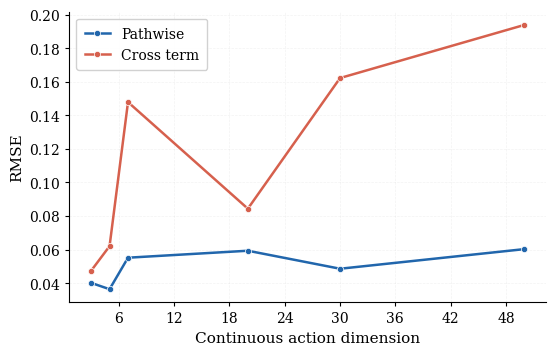

Saved to Figures/rmse_vs_gap.pdf


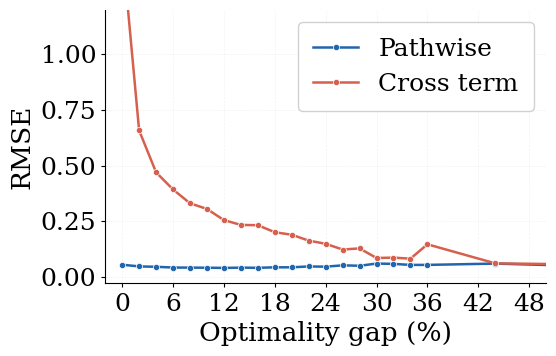

In [103]:
if __name__ == "__main__":

# Plot alignment metrics: x=stores, fixed gap bucket
    plot_metric_vs_x(
        df=bucketed_df,
        x_key=x_key,
        filter_key="bucket_left",
        filter_value=BUCKET,
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlabel="Continuous action dimension",
        legend_names=legend_names,
        out_file=f"Figures/{out_file_prefix}_vs_stores.pdf",
    )
 
    # legend_names = ["CrossAlign (pathwise)", "CrossAlign (mixed)", "Signal ratio"]

    # Plot alignment metrics: x=opt gap, fixed stores
    plot_metric_vs_x(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Optimality gap (%)",
        filter_key=x_key,
        # filter_value=20,
        filter_value=stores,
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlim=xlim,
        ylim=[-0.03, 1.2],
        legend_names=legend_names,
        out_file=f"Figures/{out_file_prefix}_vs_gap.pdf",
        font_size=19,
        show_legend=True,
    )

Saved to Figures/rmse_ppo_hybrid.pdf

Plotted data points:
 bucket_left  stores                                                  metric metric_name filter_name          y
        30.0     1.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.042214
        30.0     3.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.152327
        30.0     5.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.068073
        30.0     7.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.111604
        30.0    20.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.077766
        30.0    30.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.129501
        30.0    50.0 train/sqrt_noise_512/continuous/pathwise_plus_cross_ppo       Mixed      30–35%   0.196848
         5.0     1.0 train/sqrt_noise_512/con

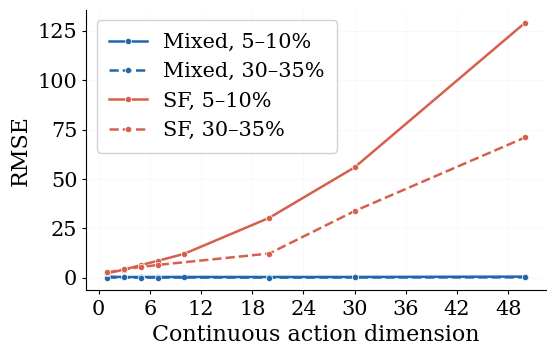

Saved to Figures/rmse_multi_stores.pdf


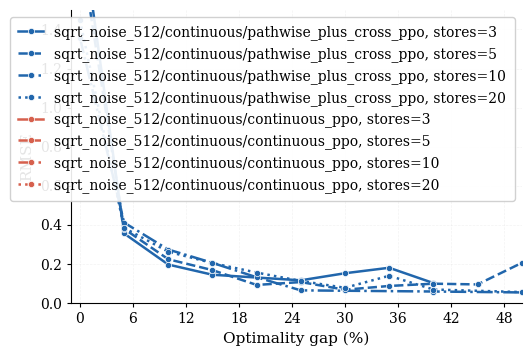

In [110]:
if __name__ == "__main__":

    plot_metric_vs_x_multi(
    df=bucketed_df,
    x_key="stores",
    filter_key="bucket_left",
    filter_values=[5.0, 30.0],
    value_metrics=vm,
    bucket_width=BUCKET_WIDTH,
    ylabel=ylabel,
    xlabel="Continuous action dimension",
    metric_names=["Mixed", "SF"],               # one per metric → color
    # metric_names=["Mixed", "REINFORCE"],               # one per metric → color
    # filter_names=["(low)", "(high)"],  # one per filter_value → linestyle
    filter_names=["5–10%", "30–35%"],  # one per filter_value → linestyle
    # legend_title="Agent, regime",              # optional
    out_file=f"Figures/{out_file_prefix}_ppo_hybrid.pdf",
    font_size=16,
    # ylim=[-0.4, 8],
    print_plotted_data=True,
    # y_jump=[20, 23]
)
 
    # Compare multiple store counts, x=opt-gap bucket
    plot_metric_vs_x_multi(
        df=bucketed_df,
        x_key="bucket_left",
        xlabel="Optimality gap (%)",
        filter_key="stores",
        filter_values=[3, 5, 10, 20],
        value_metrics=vm,
        bucket_width=BUCKET_WIDTH,
        ylabel=ylabel,
        xlim=[-1, 50],
        ylim=ylim,
        out_file=f"Figures/{out_file_prefix}_multi_stores.pdf",
    )

/tmp/ipykernel_126236/2976424843.py:431: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


Saved to Figures/signal_ratio_vs_cosine.pdf


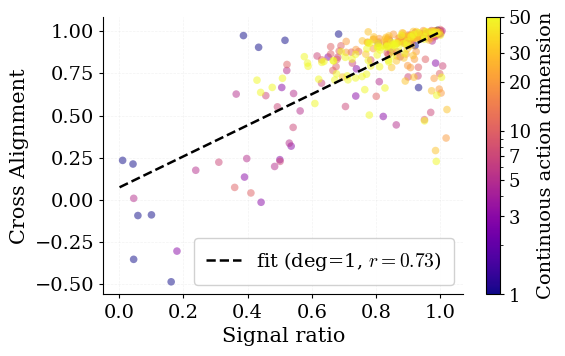

In [ ]:
if __name__ == "__main__":
# Scatter: signal ratio vs cosine similarity
    plot_scatter_with_regression(
        df=bucketed_df,
        x_metric=f"signal_{d}_ratio",
        y_metric=f"train/loo_cosine_{d}/continuous/pathwise_vs_pathwise_plus_cross_ppo/mean",
        color_key="stores",
        bucket_width=BUCKET_WIDTH,
        filter_key=None,
        filter_value=None,
        xlabel="Signal ratio",
        ylabel="Cross Alignment",
        show_regression=True,
        regression_degree=1,
        point_size=30,
        alpha=0.5,
        jitter=0.01,
        cmap_name="plasma",
        out_file="Figures/signal_ratio_vs_cosine.pdf",
        font_size=15,
        colorbar_label="Continuous action dimension"
    )

/tmp/ipykernel_126236/2976424843.py:431: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


Saved to Figures/signal_ratio_vs_cosine.pdf


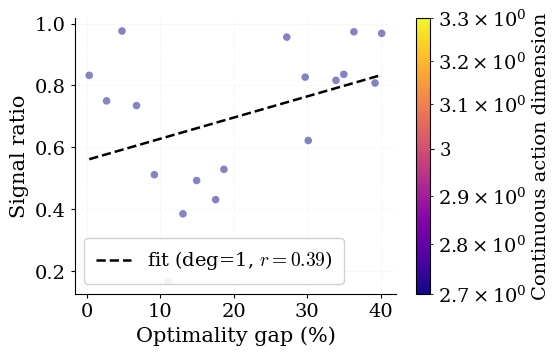

In [11]:
if __name__ == "__main__":
# Scatter: signal ratio vs cosine similarity
    plot_scatter_with_regression(
        df=bucketed_df,
        x_metric="opt_gap",
        y_metric=f"signal_{d}_ratio",
        color_key="stores",
        bucket_width=BUCKET_WIDTH,
        filter_key="stores",
        filter_value=3,
        xlabel="Optimality gap (%)",
        ylabel="Signal ratio",
        show_regression=True,
        regression_degree=1,
        point_size=30,
        alpha=0.5,
        jitter=0.01,
        cmap_name="plasma",
        out_file="Figures/signal_ratio_vs_cosine.pdf",
        font_size=15,
        colorbar_label="Continuous action dimension"
    )

### Empirical performance

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wandb
from scipy import stats as scipy_stats

WANDB_ENTITY = "alvomatias_project"
WANDB_PROJECT = "inventory_control"
PERFORMANCE_METRIC = "test/loss/reported"


# ---------------------------------------------------------------------------
# Data fetching
# ---------------------------------------------------------------------------

def fetch_sweep_runs(
    sweep_name: str,
    wandb_project: str = WANDB_PROJECT,
) -> list:
    api = wandb.Api()
    sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
    runs = list(sweep.runs)
    print(f"Fetched {len(runs)} runs from sweep {sweep_name}")
    return runs


def fetch_agent_performance(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str | None = None,
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    loss_multiplier_keys: list[str] | None = None,
) -> pd.DataFrame:
    """
    Fetches runs from one or more sweeps and returns a DataFrame with one row
    per run containing the agent type, x_key value, optional group_key value,
    and metric value.
    """
    if agent_rename is None:
        agent_rename = {}
    if filters is None:
        filters = {}

    def _passes_filter(cfg: dict) -> bool:
        for fkey, fval in filters.items():
            if fkey not in cfg:
                return False
            v = cfg[fkey]
            if isinstance(fval, (list, set)):
                if v not in fval:
                    return False
            elif isinstance(fval, tuple):
                lo, hi = fval
                if lo is not None and v < lo:
                    return False
                if hi is not None and v > hi:
                    return False
            else:
                if v != fval:
                    return False
        return True

    records = []
    seen_run_ids = set()

    for sweep_name in sweep_names:
        runs = fetch_sweep_runs(sweep_name, wandb_project=wandb_project)
        for run in runs:
            if run.id in seen_run_ids:
                continue
            seen_run_ids.add(run.id)

            cfg = run.config

            if not _passes_filter(cfg):
                continue

            try:
                agent_type = cfg["hyperparams_config"]["agent_params"]["agent_type"]
            except (KeyError, TypeError):
                print(f"Skipping run {run.id}: could not find agent_type in hyperparams_config")
                continue

            if x_key not in cfg:
                print(f"Skipping run {run.id}: missing config key '{x_key}'")
                continue
            x_val = cfg[x_key]

            group_val = None
            if group_key is not None:
                if group_key not in cfg:
                    print(f"Skipping run {run.id}: missing config key '{group_key}'")
                    continue
                group_val = cfg[group_key]

            metric_val = run.summary.get(metric)
            if metric_val is None:
                print(f"Skipping run {run.id} ({agent_type}, {x_key}={x_val}): "
                      f"metric '{metric}' not in summary")
                continue

            agent_label = agent_rename.get(agent_type, agent_type)
            metric_val_scaled = float(metric_val)
            if loss_multiplier_keys:
                for mkey in loss_multiplier_keys:
                    parts = mkey.split(".")
                    node = cfg
                    val = None
                    try:
                        for part in parts:
                            node = node[part]
                        val = node
                    except (KeyError, TypeError):
                        pass
                    if val is not None:
                        metric_val_scaled *= float(val)
                    else:
                        print(f"Warning: run {run.id} missing multiplier key "
                              f"'{mkey}', skipping it")
            record = {
                "agent": agent_label,
                x_key: x_val,
                "metric_value": metric_val_scaled,
            }
            if group_key is not None:
                record[group_key] = group_val
            records.append(record)

    df = pd.DataFrame(records)
    print(f"\nTotal valid runs: {len(df)}")
    if not df.empty:
        group_cols = ["agent", x_key] + ([group_key] if group_key else [])
        print(df.groupby(group_cols).size().rename("n_runs").to_string())
    return df


# ---------------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------------

def compute_performance_stats(
    df: pd.DataFrame,
    x_key: str = "stores",
    group_key: str | None = None,
    aggregation: str = "mean",
    relative: bool = False,
    exclude_baseline: bool = False,
    baseline_agent: str | None = None,
    exclude_points: list[tuple] | None = None,
    ci_level: float = 0.95,
) -> pd.DataFrame:
    """
    Computes aggregated performance and confidence interval for each
    (agent, x_key, [group_key]) combination.
    """
    result_df = df.copy()

    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            g_val = point[1] if len(point) > 1 else None
            mask = result_df[x_key] == x_val
            if group_key is not None and g_val is not None:
                mask &= result_df[group_key] == g_val
            n_dropped = mask.sum()
            if n_dropped > 0:
                gstr = f", {group_key}={g_val}" if (group_key and g_val is not None) else ""
                print(f"Excluding {n_dropped} rows at {x_key}={x_val}{gstr}")
            result_df = result_df[~mask]

    group_cols = ["agent", x_key] + ([group_key] if group_key else [])
    x_group_cols = [x_key] + ([group_key] if group_key else [])
    z = scipy_stats.norm.ppf(0.5 + ci_level / 2)

    if relative:
        if baseline_agent is not None:
            def _agg(vals):
                if aggregation == "median":
                    return np.median(vals)
                elif aggregation == "min":
                    return np.min(vals)
                else:
                    return np.mean(vals)

            baseline_df = (
                result_df[result_df["agent"] == baseline_agent]
                .groupby(x_group_cols)["metric_value"]
                .apply(_agg)
                .rename("baseline_val")
                .reset_index()
            )
            result_df = result_df.merge(baseline_df, on=x_group_cols, how="left")
        else:
            best_per_x = (
                result_df.groupby(x_group_cols)["metric_value"]
                .min()
                .rename("baseline_val")
                .reset_index()
            )
            result_df = result_df.merge(best_per_x, on=x_group_cols, how="left")

        result_df["metric_value"] = (
            result_df["metric_value"] / result_df["baseline_val"] - 1.0
        ) * 100.0
        result_df = result_df.drop(columns=["baseline_val"])

    if exclude_baseline and baseline_agent is not None:
        result_df = result_df[result_df["agent"] != baseline_agent]

    records = []
    for keys, grp in result_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(group_cols, keys))
        vals = grp["metric_value"].dropna().values
        n = len(vals)

        if aggregation == "mean":
            center = vals.mean()
            se = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
            ci_lo = center - z * se
            ci_hi = center + z * se

        elif aggregation == "median":
            center = np.median(vals)
            if n > 1:
                boots = [
                    np.median(np.random.choice(vals, size=n, replace=True))
                    for _ in range(2000)
                ]
                ci_lo, ci_hi = np.percentile(boots, [100*(1-ci_level)/2,
                                                      100*(1+ci_level)/2])
            else:
                ci_lo = ci_hi = center

        elif aggregation == "min":
            center = vals.min()
            ci_lo = ci_hi = center

        else:
            raise ValueError(f"aggregation must be 'mean', 'median', or 'min'; got '{aggregation}'")

        records.append({**key_dict, "center": center, "ci_lo": ci_lo, "ci_hi": ci_hi, "n": n})

    stats_df = (
        pd.DataFrame(records)
        .sort_values(group_cols)
        .reset_index(drop=True)
    )
    return stats_df


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_agent_comparison(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str | None = None,
    aggregation: str = "mean",
    relative: bool = False,
    exclude_baseline: bool = False,
    baseline_agent: str | None = None,
    agent_rename: dict[str, str] | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    ci_level: float = 0.95,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    ci_alpha: float = 0.12,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    agent_colors: dict | None = None,
    agent_linestyles: dict | None = None,
    group_label_fmt: str | None = None,
    show_title: bool = False,
    loss_multiplier_keys: list[str] | None = None,
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    Fetches runs from one or more sweeps and plots aggregated performance
    with confidence intervals. One line per agent (or per agent × group_key).
    """
    raw_df = fetch_agent_performance(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        group_key=group_key,
        agent_rename=agent_rename,
        wandb_project=wandb_project,
        filters=filters,
        loss_multiplier_keys=loss_multiplier_keys,
    )
    if raw_df.empty:
        print("No data found.")
        return raw_df

    np.random.seed(42)
    stats_df = compute_performance_stats(
        raw_df,
        x_key=x_key,
        group_key=group_key,
        aggregation=aggregation,
        relative=relative,
        exclude_baseline=exclude_baseline,
        baseline_agent=baseline_agent,
        exclude_points=exclude_points,
        ci_level=ci_level,
    )

    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)

    if group_key is not None:
        line_keys = (
            stats_df[["agent", group_key]]
            .drop_duplicates()
            .sort_values(["agent", group_key])
            .values.tolist()
        )
    else:
        line_keys = [[a] for a in sorted(stats_df["agent"].unique())]

    agents_sorted = sorted(stats_df["agent"].unique())

    _default_colors = [
        "#2166ac", "#d6604d", "#4dac26", "#8073ac",
        "#e08214", "#01665e", "#f6e8c3", "#542788",
    ]
    _default_linestyles = ["-", "--", "-.", ":"]

    if group_key is not None:
        group_vals = sorted(stats_df[group_key].unique())
        group_color = {
            g: (agent_colors or {}).get(str(g), _default_colors[i % len(_default_colors)])
            for i, g in enumerate(group_vals)
        }
        _ls_map = agent_linestyles or {}
        agent_ls = {
            a: _ls_map.get(a, _default_linestyles[i % len(_default_linestyles)])
            for i, a in enumerate(agents_sorted)
        }
    else:
        _color_map = agent_colors or {}
        agent_color = {
            a: _color_map.get(a, _default_colors[i % len(_default_colors)])
            for i, a in enumerate(agents_sorted)
        }
        _ls_map = agent_linestyles or {}
        agent_ls = {
            a: _ls_map.get(a, "-")
            for a in agents_sorted
        }

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],  # matplotlib's best built-in serif
        "mathtext.fontset": "cm",        # Computer Modern for math only
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })

    fig, ax = plt.subplots(figsize=figsize)

    for key in line_keys:
        if group_key is not None:
            agent, gval = key
            mask = (stats_df["agent"] == agent) & (stats_df[group_key] == gval)
            color = group_color[gval]
            ls = agent_ls[agent]
            if group_label_fmt is not None:
                _glabel = group_label_fmt.format(val=gval)
            else:
                _glabel = f"{group_key}={gval}"
            label = (
                f"{agent}, {_glabel}"
                if len(agents_sorted) > 1
                else _glabel
            )
        else:
            agent = key[0]
            mask = stats_df["agent"] == agent
            color = agent_color[agent]
            ls = agent_ls[agent]
            label = agent

        sub = stats_df[mask].sort_values(x_key)
        ax.plot(
            sub[x_key], sub["center"],
            marker="o", label=label, color=color,
            linestyle=ls, lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )

        if aggregation != "min":
            ax.fill_between(
                sub[x_key], sub["ci_lo"], sub["ci_hi"],
                alpha=ci_alpha, color=color, linewidth=0,
            )

    ax.set_xlabel(
        xlabel if xlabel is not None else x_key,
        fontsize=font_size,
    )

    if ylabel is not None:
        _ylabel = ylabel
    elif relative:
        baseline_lbl = f" vs {baseline_agent}" if baseline_agent else ""
        _ylabel = f"% above baseline{baseline_lbl}"
    else:
        agg_label = {"mean": "Mean", "median": "Median", "min": "Min"}[aggregation]
        _ylabel = f"{agg_label} test loss"
    ax.set_ylabel(_ylabel, fontsize=font_size)

    if show_title:
        _title = title if title is not None else f"Agent comparison ({aggregation})"
        ax.set_title(_title, fontsize=font_size + 1)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    ax.legend(
        fontsize=_legend_fs,
        framealpha=0.9,
        edgecolor="0.8",
        borderpad=0.6,
        handlelength=1.8,
    )
    fig.tight_layout(pad=0.5)

    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()

    return stats_df


# ---------------------------------------------------------------------------
# LaTeX table generation
# ---------------------------------------------------------------------------

def generate_latex_table(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str | None = None,
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,
    agents_order: list[str] | None = None,
    x_label: str | None = None,
    group_key_label: str | None = None,
    group_label_fmt: str | None = None,
    caption: str = "Performance results.",
    label: str = "tab:results",
    float_fmt: str = ".3f",
    loss_multiplier_keys: list[str] | None = None,
    split_agent_by_config: dict[str, dict[str, tuple[str, str]]] | None = None,
) -> str:
    """
    Generates a LaTeX table with double headers (one per agent) and columns
    Mean ± Std, Median for each agent.

    Parameters
    ----------
    split_agent_by_config : dict, optional
        Splits one logical agent into two display columns by fetching it twice
        with different config filters.
        Format:
            {
                "<agent_name>": {
                    "<config_key>": ("<label_when_False>", "<label_when_True>")
                }
            }
        Example:
            {
                "HPO": {
                    "disable_cross_term": ("HPOFull", "HPONoCross")
                }
            }
        Internally this calls fetch_agent_performance twice for the split agent
        (once filtering config_key=False, once =True) and concatenates with
        the base fetch for all other agents.
    """
    split_agent_by_config = split_agent_by_config or {}

    # ── Fetch base data (all agents, used as-is for non-split agents) ─────────
    raw_df = fetch_agent_performance(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        group_key=group_key,
        agent_rename=agent_rename,
        wandb_project=wandb_project,
        filters=filters,
        loss_multiplier_keys=loss_multiplier_keys,
    )

    # ── Handle splits: re-fetch the split agent with each config variant ──────
    _split_expansion: dict[str, list[str]] = {}

    for base_agent, rules in split_agent_by_config.items():
        for config_key, (label_false, label_true) in rules.items():
            _split_expansion[base_agent] = [label_false, label_true]

            # Drop original rows for this agent from the base df
            raw_df = raw_df[raw_df["agent"] != base_agent].copy()

            # Determine the display name before renaming (agent_rename may have
            # already mapped the internal name → base_agent display name, so we
            # need the *pre-rename* key to pass as agent_rename override)
            pre_rename_key = base_agent
            if agent_rename:
                # invert to find the original sweep agent name
                inv = {v: k for k, v in agent_rename.items()}
                pre_rename_key = inv.get(base_agent, base_agent)

            for flag_val, sub_label in [(False, label_false), (True, label_true)]:
                extra_filter = {config_key: flag_val}
                combined_filters = {**(filters or {}), **extra_filter}

                sub_df = fetch_agent_performance(
                    sweep_names=sweep_names,
                    metric=metric,
                    x_key=x_key,
                    group_key=group_key,
                    agent_rename=agent_rename,
                    wandb_project=wandb_project,
                    filters=combined_filters,
                    loss_multiplier_keys=loss_multiplier_keys,
                )
                sub_df = sub_df[sub_df["agent"] == base_agent].copy()
                sub_df["agent"] = sub_label
                raw_df = pd.concat([raw_df, sub_df], ignore_index=True)

    # ── Exclude points ────────────────────────────────────────────────────────
    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            g_val = point[1] if len(point) > 1 else None
            mask = raw_df[x_key] == x_val
            if group_key is not None and g_val is not None:
                mask &= raw_df[group_key] == g_val
            raw_df = raw_df[~mask]

    # ── Build agents list, expanding splits in-place ──────────────────────────
    if agents_order is not None:
        agents = []
        for a in agents_order:
            if a in _split_expansion:
                agents.extend(_split_expansion[a])
            else:
                agents.append(a)
    else:
        agents = sorted(raw_df["agent"].unique())

    # ── Aggregate statistics ──────────────────────────────────────────────────
    row_keys = [x_key] + ([group_key] if group_key else [])

    records = []
    for keys, grp in raw_df.groupby(["agent"] + row_keys):
        if not isinstance(keys, tuple):
            keys = (keys,)
        agent = keys[0]
        row_vals = dict(zip(row_keys, keys[1:]))
        vals = grp["metric_value"].dropna().values
        n = len(vals)
        records.append({
            "agent": agent,
            **row_vals,
            "mean":   vals.mean(),
            "std":    vals.std(ddof=1) if n > 1 else 0.0,
            "median": np.median(vals),
            "n":      n,
        })

    stats_df = pd.DataFrame(records)

    row_index = (
        stats_df[row_keys]
        .drop_duplicates()
        .sort_values(row_keys)
        .values.tolist()
    )

    # ── Formatting helpers ────────────────────────────────────────────────────
    def _fmt(v: float) -> str:
        return format(v, float_fmt)

    def _row_cells(vals: list) -> list[str]:
        parts = []
        for key, v in zip(row_keys, vals):
            if key == group_key and group_label_fmt is not None:
                parts.append(group_label_fmt.format(val=v))
            else:
                parts.append(str(v))
        return parts

    def _safe_header(h: str) -> str:
        if "_" in h and not h.startswith("$"):
            return f"\\textbf{{${h}$}}"
        return f"\\textbf{{{h}}}"

    # ── LaTeX assembly ────────────────────────────────────────────────────────
    n_agents = len(agents)
    n_metric_cols = 2          # Mean ± Std, Median
    n_row_cols = len(row_keys)

    col_spec = "l" * n_row_cols + ("rr" * n_agents)

    _xl = x_label if x_label is not None else x_key
    _gl = group_key_label if group_key_label is not None else (
        f"${group_key}$" if group_key and "_" in group_key else group_key
    )
    row_headers = [_xl] + ([_gl] if group_key else [])

    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(f"  \\caption{{{caption}}}")
    lines.append(f"  \\label{{{label}}}")
    lines.append(f"  \\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"    \toprule")

    row_placeholder = " & ".join([""] * n_row_cols)
    agent_headers = " & ".join(
        f"\\multicolumn{{{n_metric_cols}}}{{c}}{{\\textbf{{{a}}}}}" for a in agents
    )
    lines.append(f"    {row_placeholder} & {agent_headers} \\\\")

    cmidrules = []
    for i in range(n_agents):
        start = n_row_cols + i * n_metric_cols + 1
        end   = start + n_metric_cols - 1
        cmidrules.append(f"\\cmidrule(lr){{{start}-{end}}}")
    lines.append("    " + " ".join(cmidrules))

    row_col_headers = " & ".join(_safe_header(h) for h in row_headers)
    metric_headers  = " & ".join(
        ["\\textbf{Mean $\\pm$ Std} & \\textbf{Median}"] * n_agents
    )
    lines.append(f"    {row_col_headers} & {metric_headers} \\\\")
    lines.append(r"    \midrule")

    for row_vals in row_index:
        if not isinstance(row_vals, list):
            row_vals = [row_vals]
        cells = _row_cells(row_vals)

        for agent in agents:
            mask = stats_df["agent"] == agent
            for key, v in zip(row_keys, row_vals):
                mask &= stats_df[key] == v
            sub = stats_df[mask]

            if sub.empty:
                cells += ["--", "--"]
            else:
                r = sub.iloc[0]
                mean_std = f"${_fmt(r['mean'])} \\pm {_fmt(r['std'])}$"
                cells.append(mean_std)
                cells.append(f"${_fmt(r['median'])}$")

        lines.append("    " + " & ".join(cells) + r" \\")

    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")

    return "\n".join(lines)

# ---------------------------------------------------------------------------
# Condition comparison plot (e.g. cross term vs no cross term)
# ---------------------------------------------------------------------------

def plot_condition_comparison(
    sweep_names: list[str],
    condition_key: str,
    condition_baseline,
    condition_treatment,
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str = "batch_size",
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,
    aggregation: str = "mean",
    ci_level: float = 0.95,
    loss_multiplier_keys: list[str] | None = None,
    group_label_fmt: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    ci_alpha: float = 0.12,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    show_title: bool = False,
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    Plots the relative gap between two conditions of a single config key,
    with one line per value of group_key and x-axis indexed by x_key.

    The y-axis shows:
        (treatment_agg - baseline_agg) / baseline_agg * 100  (%)

    with bootstrapped 95% CIs on the gap.
    """
    np.random.seed(42)
    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)

    raw_df = fetch_agent_performance(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        group_key=group_key,
        agent_rename=agent_rename,
        wandb_project=wandb_project,
        filters=filters,
        loss_multiplier_keys=loss_multiplier_keys,
    )
    if raw_df.empty:
        print("No data found.")
        return raw_df

    api = wandb.Api()
    condition_vals = {}
    seen = set()
    for sweep_name in sweep_names:
        sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
        for run in sweep.runs:
            if run.id in seen:
                continue
            seen.add(run.id)
            cval = run.config.get(condition_key)
            if cval is None:
                parts = condition_key.split(".")
                node = run.config
                try:
                    for p in parts:
                        node = node[p]
                    cval = node
                except (KeyError, TypeError):
                    cval = None
            condition_vals[run.id] = cval

    records2 = []
    seen2 = set()
    if filters is None:
        filters = {}

    def _passes(cfg):
        for fkey, fval in filters.items():
            v = cfg.get(fkey)
            if v is None:
                return False
            if isinstance(fval, (list, set)):
                if v not in fval:
                    return False
            elif isinstance(fval, tuple):
                lo, hi = fval
                if lo is not None and v < lo:
                    return False
                if hi is not None and v > hi:
                    return False
            else:
                if v != fval:
                    return False
        return True

    for sweep_name in sweep_names:
        sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
        for run in sweep.runs:
            if run.id in seen2:
                continue
            seen2.add(run.id)
            cfg = run.config
            if not _passes(cfg):
                continue
            x_val = cfg.get(x_key)
            g_val = cfg.get(group_key)
            metric_val = run.summary.get(metric)
            if any(v is None for v in [x_val, g_val, metric_val]):
                continue
            cval = condition_vals.get(run.id)
            if cval is None:
                continue
            mval = float(metric_val)
            if loss_multiplier_keys:
                for mkey in loss_multiplier_keys:
                    parts = mkey.split(".")
                    node = cfg
                    try:
                        for part in parts:
                            node = node[part]
                        mval *= float(node)
                    except (KeyError, TypeError):
                        pass
            records2.append({
                x_key: x_val,
                group_key: g_val,
                "condition": cval,
                "metric_value": mval,
            })

    df = pd.DataFrame(records2)
    if df.empty:
        print("No data after condition extraction.")
        return df

    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            g_val = point[1] if len(point) > 1 else None
            mask = df[x_key] == x_val
            if g_val is not None:
                mask &= df[group_key] == g_val
            df = df[~mask]

    def _agg(vals):
        if aggregation == "median":
            return np.median(vals)
        elif aggregation == "min":
            return np.min(vals)
        return np.mean(vals)

    def _bootstrap_gap(base_vals, treat_vals, n_boot=2000):
        gaps = []
        for _ in range(n_boot):
            b = _agg(np.random.choice(base_vals, size=len(base_vals), replace=True))
            t = _agg(np.random.choice(treat_vals, size=len(treat_vals), replace=True))
            if b > 0:
                gaps.append((t - b) / b * 100)
        gap = (_agg(treat_vals) - _agg(base_vals)) / _agg(base_vals) * 100
        lo, hi = np.percentile(gaps, [100*(1-ci_level)/2, 100*(1+ci_level)/2])
        return gap, lo, hi

    x_vals = sorted(df[x_key].unique())
    group_vals = sorted(df[group_key].unique())

    records_out = []
    for gval in group_vals:
        for xval in x_vals:
            base = df[
                (df[x_key] == xval) &
                (df[group_key] == gval) &
                (df["condition"] == condition_baseline)
            ]["metric_value"].dropna().values
            treat = df[
                (df[x_key] == xval) &
                (df[group_key] == gval) &
                (df["condition"] == condition_treatment)
            ]["metric_value"].dropna().values
            if len(base) == 0 or len(treat) == 0:
                continue
            gap, lo, hi = _bootstrap_gap(base, treat)
            records_out.append({
                x_key: xval, group_key: gval,
                "gap": gap, "ci_lo": lo, "ci_hi": hi,
            })

    result_df = pd.DataFrame(records_out)

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],  # matplotlib's best built-in serif
        "mathtext.fontset": "cm",        # Computer Modern for math only
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })

    _default_colors = [
        "#2166ac", "#d6604d", "#4dac26", "#8073ac",
        "#e08214", "#01665e", "#542788", "#bf812d",
    ]

    fig, ax = plt.subplots(figsize=figsize)

    for i, gval in enumerate(group_vals):
        sub = result_df[result_df[group_key] == gval].sort_values(x_key)
        color = _default_colors[i % len(_default_colors)]
        if group_label_fmt is not None:
            label = group_label_fmt.format(val=gval)
        else:
            label = f"{group_key}={gval}"
        ax.plot(
            sub[x_key], sub["gap"],
            marker="o", label=label, color=color,
            lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )
        ax.fill_between(
            sub[x_key], sub["ci_lo"], sub["ci_hi"],
            alpha=ci_alpha, color=color, linewidth=0,
        )

    ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.4)
    ax.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)
    _ylabel = ylabel if ylabel is not None else \
        f"Excess {aggregation} loss of treatment over baseline (%)"
    ax.set_ylabel(_ylabel, fontsize=font_size)

    if show_title:
        ax.set_title(
            f"Effect of {condition_key}: {condition_treatment} vs {condition_baseline}",
            fontsize=font_size + 1,
        )

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    ax.legend(fontsize=_legend_fs, framealpha=0.9, edgecolor="0.8",
              borderpad=0.6, handlelength=1.8)
    fig.tight_layout(pad=0.5)

    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()

    return result_df


# ---------------------------------------------------------------------------
# Batch-trainer-pair comparison plot
# ---------------------------------------------------------------------------

def _normalize_btp(val) -> tuple:
    """
    Normalise a batch_trainer_pair value (list, tuple, or string) to a
    hashable tuple so it can be used as a dict key / groupby value.
    """
    if isinstance(val, (list, tuple)):
        return tuple(val)
    if isinstance(val, str):
        # e.g. "[128, 200]" -> (128, 200)
        cleaned = val.strip().strip("[]()").replace(" ", "")
        try:
            return tuple(int(x) for x in cleaned.split(","))
        except ValueError:
            return (val,)
    return (val,)


def _fetch_raw_for_btp(
    sweep_names: list[str],
    metric: str,
    x_key: str,
    batch_trainer_pair_key: str,
    agent_rename: dict[str, str],
    wandb_project: str,
    filters: dict,
    loss_multiplier_keys: list[str] | None,
) -> pd.DataFrame:
    """
    Low-level fetch that reads x_key, batch_trainer_pair_key, agent_type,
    and the metric for every valid run. Returns a raw DataFrame.
    """
    def _passes(cfg: dict) -> bool:
        for fkey, fval in filters.items():
            v = cfg.get(fkey)
            if v is None:
                return False
            if isinstance(fval, (list, set)):
                if v not in fval:
                    return False
            elif isinstance(fval, tuple):
                lo, hi = fval
                if lo is not None and v < lo:
                    return False
                if hi is not None and v > hi:
                    return False
            else:
                if v != fval:
                    return False
        return True

    api = wandb.Api()
    records = []
    seen = set()

    for sweep_name in sweep_names:
        sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
        for run in sweep.runs:
            if run.id in seen:
                continue
            seen.add(run.id)
            cfg = run.config

            if not _passes(cfg):
                continue

            try:
                agent_type = cfg["hyperparams_config"]["agent_params"]["agent_type"]
            except (KeyError, TypeError):
                continue

            x_val = cfg.get(x_key)
            btp_val = cfg.get(batch_trainer_pair_key)
            metric_val = run.summary.get(metric)

            if any(v is None for v in [x_val, btp_val, metric_val]):
                continue

            agent_label = agent_rename.get(agent_type, agent_type)
            btp_key = _normalize_btp(btp_val)

            mval = float(metric_val)
            if loss_multiplier_keys:
                for mkey in loss_multiplier_keys:
                    parts = mkey.split(".")
                    node = cfg
                    try:
                        for part in parts:
                            node = node[part]
                        mval *= float(node)
                    except (KeyError, TypeError):
                        pass

            records.append({
                "agent": agent_label,
                x_key: x_val,
                "btp": btp_key,          # normalised tuple, e.g. (128, 200)
                "metric_value": mval,
            })

    df = pd.DataFrame(records)
    print(f"Fetched {len(df)} valid runs across all sweeps.")
    if not df.empty:
        print(df.groupby(["agent", x_key, "btp"]).size().rename("n_runs").to_string())
    return df


def plot_batch_pair_comparison(
    sweep_names: list[str],
    agent_filter: str,
    reference_agent: str,
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    batch_trainer_pair_key: str = "batch_trainer_pair",
    top_k_reference: int = 5,
    aggregation: str = "mean",         # "mean" | "median" | "min"
    ci_level: float = 0.95,            # set to 0 to suppress CI bands
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,  # list of (x_val, btp_tuple) to drop
    loss_multiplier_keys: list[str] | None = None,
    # ── legend / labels ─────────────────────────────────────────────────────
    btp_label_fmt: str | None = None,  # e.g. "B={0}, T={1}" where {0},{1} are
                                        # the elements of the btp tuple.
                                        # If None: "(128, 200)"
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    show_title: bool = False,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    # ── aesthetics ───────────────────────────────────────────────────────────
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    ci_alpha: float = 0.12,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    btp_colors: dict | None = None,    # map btp tuple -> colour
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    For a single agent (``agent_filter``), plots one line per
    ``batch_trainer_pair`` value.  The y-axis shows the relative gap vs a
    fixed reference:

        y = (mean_loss(agent, x, btp) - ref(x)) / ref(x) * 100  [%]

    where

        ref(x) = mean of the top-``top_k_reference`` lowest metric values
                 among all ``reference_agent`` runs at that x value,
                 across all btp values.

    The reference is treated as a fixed scalar per x (no added variability).
    CIs on y are computed by bootstrapping only the agent runs:

        ci on y  ←  bootstrap distribution of
                     (agg(boot_agent_runs) - ref) / ref * 100

    Setting ``ci_level=0`` disables CI bands entirely (equivalent to
    ``aggregation="min"`` behaviour for CI suppression).

    Parameters
    ----------
    sweep_names          : list of W&B sweep IDs
    agent_filter         : display name of the agent whose lines to plot
                           (e.g. "PPO" or "HPO")
    reference_agent      : display name of the agent used to build the
                           reference (e.g. "HPO")
    metric               : W&B summary metric key
    x_key                : config key for x-axis (e.g. "stores")
    batch_trainer_pair_key : config key storing [batch, trainer_steps]
                             (e.g. "batch_trainer_pair")
    top_k_reference      : number of best (lowest) reference-agent runs
                           per x value used to compute ref(x)
    aggregation          : how to aggregate agent runs per (x, btp):
                           "mean" | "median" | "min"
    ci_level             : confidence level for bootstrap CI bands.
                           Set to 0 to suppress CI entirely.
    agent_rename         : dict mapping raw W&B agent_type -> display name
    wandb_project        : W&B project name
    filters              : run-level filters (same syntax as plot_agent_comparison)
    exclude_points       : list of (x_val, btp_tuple) pairs to drop before
                           aggregation, e.g. [(8, (128, 200)), (16, (256, 100))]
    loss_multiplier_keys : optional config keys to multiply into the metric
    btp_label_fmt        : format string for legend labels. Uses Python
                           str.format(*btp_tuple), so "{0}" is the first
                           element, "{1}" the second, etc.
                           e.g. "B={0}, T={1}" → "B=128, T=200"
                           If None, the raw tuple string is used.
    xlabel / ylabel / title : axis labels / title
    show_title           : whether to render the title on the axes
    xlim / ylim          : axis limits
    figsize / font_size / etc. : standard aesthetic params
    btp_colors           : dict mapping btp tuple -> matplotlib colour
    out_file             : save path (e.g. "plot.pdf")

    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, btp, center, ci_lo, ci_hi, n, ref
    where center/ci_lo/ci_hi are in % relative to ref.
    """
    np.random.seed(42)
    if agent_rename is None:
        agent_rename = {}
    if filters is None:
        filters = {}

    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)

    # ── fetch all runs (both agent_filter and reference_agent) ───────────────
    raw_df = _fetch_raw_for_btp(
        sweep_names=sweep_names,
        metric=metric,
        x_key=x_key,
        batch_trainer_pair_key=batch_trainer_pair_key,
        agent_rename=agent_rename,
        wandb_project=wandb_project,
        filters=filters,
        loss_multiplier_keys=loss_multiplier_keys,
    )
    if raw_df.empty:
        print("No data found.")
        return raw_df

    # ── apply exclude_points ──────────────────────────────────────────────────
    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            btp_val = _normalize_btp(point[1]) if len(point) > 1 else None
            mask = raw_df[x_key] == x_val
            if btp_val is not None:
                mask &= raw_df["btp"].apply(lambda v: v == btp_val)
            n_dropped = mask.sum()
            if n_dropped:
                print(f"Excluding {n_dropped} rows at {x_key}={x_val}, btp={btp_val}")
            raw_df = raw_df[~mask]

    # ── build reference: top-K best reference_agent runs per x ───────────────
    ref_df = raw_df[raw_df["agent"] == reference_agent].copy()
    if ref_df.empty:
        raise ValueError(
            f"No runs found for reference agent '{reference_agent}'. "
            f"Check agent_rename and sweep data."
        )

    ref_per_x = {}
    for x_val, grp in ref_df.groupby(x_key):
        sorted_vals = grp["metric_value"].dropna().sort_values().values
        top_k = sorted_vals[:top_k_reference]   # smallest = best
        ref_per_x[x_val] = float(top_k.mean())

    print("\nReference values per x:")
    for x_val, ref_val in sorted(ref_per_x.items()):
        print(f"  {x_key}={x_val}: ref={ref_val:.4f}  "
              f"(mean of top-{top_k_reference} {reference_agent} runs)")

    # ── filter to agent_filter only ───────────────────────────────────────────
    agent_df = raw_df[raw_df["agent"] == agent_filter].copy()
    if agent_df.empty:
        raise ValueError(
            f"No runs found for agent '{agent_filter}'. "
            f"Check agent_rename and sweep data."
        )

    # ── aggregation helpers ───────────────────────────────────────────────────
    def _agg(vals: np.ndarray) -> float:
        if aggregation == "median":
            return float(np.median(vals))
        elif aggregation == "min":
            return float(np.min(vals))
        return float(np.mean(vals))

    z = scipy_stats.norm.ppf(0.5 + ci_level / 2) if ci_level > 0 else 0.0
    show_ci = ci_level > 0 and aggregation != "min"

    # ── compute per (x, btp) stats ────────────────────────────────────────────
    records_out = []
    btp_vals_all = sorted(agent_df["btp"].unique(), key=lambda t: t)

    for btp in btp_vals_all:
        for x_val in sorted(agent_df[x_key].unique()):
            vals = agent_df[
                (agent_df["btp"] == btp) & (agent_df[x_key] == x_val)
            ]["metric_value"].dropna().values

            if len(vals) == 0:
                continue

            ref = ref_per_x.get(x_val)
            if ref is None or ref == 0:
                print(f"Warning: no reference for {x_key}={x_val}, skipping.")
                continue

            center_raw = _agg(vals)
            center_pct = (center_raw - ref) / ref * 100.0
            n = len(vals)

            if show_ci:
                if aggregation == "mean":
                    # analytic CI: reference is fixed, so only agent variance matters
                    se_raw = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
                    # delta method: d(pct)/d(center_raw) = 100/ref
                    se_pct = se_raw / ref * 100.0
                    ci_lo = center_pct - z * se_pct
                    ci_hi = center_pct + z * se_pct
                else:
                    # bootstrap CI (median)
                    boots = []
                    for _ in range(2000):
                        b = _agg(np.random.choice(vals, size=n, replace=True))
                        boots.append((b - ref) / ref * 100.0)
                    ci_lo, ci_hi = np.percentile(
                        boots,
                        [100 * (1 - ci_level) / 2, 100 * (1 + ci_level) / 2],
                    )
            else:
                ci_lo = ci_hi = center_pct

            records_out.append({
                x_key: x_val,
                "btp": btp,
                "center": center_pct,
                "ci_lo": ci_lo,
                "ci_hi": ci_hi,
                "n": n,
                "ref": ref,
            })

    result_df = pd.DataFrame(records_out)
    if result_df.empty:
        print("No valid (x, btp) cells found after filtering.")
        return result_df

    # ── aesthetics ────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],  # matplotlib's best built-in serif
        "mathtext.fontset": "cm",        # Computer Modern for math only
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })

    _default_colors = [
        "#2166ac", "#d6604d", "#4dac26", "#8073ac",
        "#e08214", "#01665e", "#542788", "#bf812d",
    ]

    _btp_color_map = btp_colors or {}
    btp_color = {
        btp: _btp_color_map.get(btp, _default_colors[i % len(_default_colors)])
        for i, btp in enumerate(btp_vals_all)
    }

    def _btp_label(btp: tuple) -> str:
        if btp_label_fmt is not None:
            return btp_label_fmt.format(*btp)
        return str(btp)

    fig, ax = plt.subplots(figsize=figsize)

    for btp in btp_vals_all:
        sub = result_df[result_df["btp"] == btp].sort_values(x_key)
        if sub.empty:
            continue
        color = btp_color[btp]
        label = _btp_label(btp)
        ax.plot(
            sub[x_key], sub["center"],
            marker="o", label=label, color=color,
            lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )
        if show_ci:
            ax.fill_between(
                sub[x_key], sub["ci_lo"], sub["ci_hi"],
                alpha=ci_alpha, color=color, linewidth=0,
            )

    ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.4)

    ax.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)

    if ylabel is not None:
        _ylabel = ylabel
    else:
        agg_label = {"mean": "mean", "median": "median", "min": "min"}[aggregation]
        _ylabel = (
            f"% gap vs top-{top_k_reference} {reference_agent} ref\n"
            f"({agg_label} {agent_filter} loss)"
        )
    ax.set_ylabel(_ylabel, fontsize=font_size)

    if show_title:
        _title = title if title is not None else (
            f"{agent_filter}: per-btp gap vs {reference_agent} reference"
        )
        ax.set_title(_title, fontsize=font_size + 1)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    ax.legend(
        fontsize=_legend_fs,
        framealpha=0.9,
        edgecolor="0.8",
        borderpad=0.6,
        handlelength=1.8,
    )
    fig.tight_layout(pad=0.5)

    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()

    return result_df


# ---------------------------------------------------------------------------
# Scaling law: fetch → cache → plot
# ---------------------------------------------------------------------------

def fetch_scaling_law_data(
    sweep_names: list[str],
    cache_path: str,
    dev_metric: str = "dev/loss/reported",
    x_key: str = "stores",
    batch_trainer_pair_key: str | None = "batch_trainer_pair",
    batch_size_key: str | None = None,   # alternative to batch_trainer_pair_key;
                                          # if set, batch_size is read directly from
                                          # this config key (e.g. "batch_size" for LQR)
    extra_group_keys: list[str] | None = None,  # extra config keys to store per run
                                                  # e.g. ["n_modes"] for LQR
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
) -> pd.DataFrame:
    """
    Fetches the dev metric history for every run in the given sweeps and saves
    the result to ``cache_path`` as a parquet file.  Call this once; then use
    ``plot_scaling_law`` (which reads the cache) for all plotting iterations.

    Each row in the saved DataFrame corresponds to one run and contains:
        run_id, agent, {x_key}, batch_size, [extra_group_keys...], dev_min,
        dev_series   ← full epoch history as a Python list (one float per epoch)

    Parameters
    ----------
    sweep_names            : list of W&B sweep IDs
    cache_path             : file path to write, e.g. "scaling_cache.parquet"
    dev_metric             : W&B history metric key (e.g. "dev/loss/reported")
    x_key                  : config key for x-axis (e.g. "stores")
    batch_trainer_pair_key : config key storing [batch_size, trainer_steps].
                             Set to None if using batch_size_key instead.
    batch_size_key         : direct config key for batch size (e.g. "batch_size").
                             Used when there is no batch_trainer_pair in the config.
                             Exactly one of batch_trainer_pair_key / batch_size_key
                             must be set.
    extra_group_keys       : additional config keys to record per run, e.g.
                             ["n_modes"]. These become columns in the cache and
                             can be used as group_key in plot_scaling_law.
    agent_rename           : dict mapping raw W&B agent_type -> display name
    wandb_project          : W&B project name
    filters                : run-level config filters (same syntax as elsewhere)

    Returns
    -------
    pd.DataFrame (same as what is written to cache_path)
    """
    if agent_rename is None:
        agent_rename = {}
    if filters is None:
        filters = {}
    if extra_group_keys is None:
        extra_group_keys = []

    if batch_trainer_pair_key is None and batch_size_key is None:
        raise ValueError("Exactly one of batch_trainer_pair_key or batch_size_key must be set.")
    if batch_trainer_pair_key is not None and batch_size_key is not None:
        raise ValueError("Set only one of batch_trainer_pair_key or batch_size_key, not both.")

    def _passes(cfg: dict) -> bool:
        for fkey, fval in filters.items():
            v = cfg.get(fkey)
            if v is None:
                return False
            if isinstance(fval, (list, set)):
                if v not in fval:
                    return False
            elif isinstance(fval, tuple):
                lo, hi = fval
                if lo is not None and v < lo:
                    return False
                if hi is not None and v > hi:
                    return False
            else:
                if v != fval:
                    return False
        return True

    def _get_agent(cfg: dict) -> str | None:
        try:
            raw = cfg["hyperparams_config"]["agent_params"]["agent_type"]
            return agent_rename.get(raw, raw)
        except (KeyError, TypeError):
            return None

    api = wandb.Api()
    run_records = []
    seen = set()

    for sweep_name in sweep_names:
        sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
        runs = list(sweep.runs)
        print(f"Fetching history for {len(runs)} runs in sweep {sweep_name}...")
        for i, run in enumerate(runs):
            if run.id in seen:
                continue
            seen.add(run.id)
            cfg = run.config

            if not _passes(cfg):
                continue

            agent = _get_agent(cfg)
            if agent is None:
                continue

            x_val = cfg.get(x_key)
            if x_val is None:
                continue

            # ── resolve batch_size ────────────────────────────────────────────
            if batch_trainer_pair_key is not None:
                btp = cfg.get(batch_trainer_pair_key)
                if btp is None:
                    continue
                batch_size = int(_normalize_btp(btp)[0])
            else:
                batch_size = cfg.get(batch_size_key)
                if batch_size is None:
                    continue
                batch_size = int(batch_size)

            # ── resolve extra group keys ──────────────────────────────────────
            extra_vals = {}
            skip = False
            for gk in extra_group_keys:
                v = cfg.get(gk)
                if v is None:
                    skip = True
                    break
                extra_vals[gk] = v
            if skip:
                continue

            # ── pull dev metric history ───────────────────────────────────────
            hist = run.history(keys=[dev_metric], pandas=True)
            if hist.empty or dev_metric not in hist.columns:
                print(f"  Skipping run {run.id}: no history for '{dev_metric}'")
                continue

            dev_series = hist[dev_metric].dropna().values
            if len(dev_series) == 0:
                continue

            run_records.append({
                "run_id":     run.id,
                "agent":      agent,
                x_key:        x_val,
                "batch_size": batch_size,
                **extra_vals,
                "dev_min":    float(dev_series.min()),
                "dev_series": dev_series.tolist(),
            })

            if (i + 1) % 20 == 0:
                print(f"  {i+1}/{len(runs)} runs processed...")

    df = pd.DataFrame(run_records)
    print(f"\nFetched {len(df)} valid runs total.")
    if not df.empty:
        group_report_cols = ["agent", x_key, "batch_size"] + extra_group_keys
        print(df.groupby(group_report_cols).size().rename("n_runs").to_string())

    df.to_parquet(cache_path, index=False)
    print(f"\nCache saved to '{cache_path}'.")
    return df


def plot_scaling_law(
    cache_path: str,
    reference_agent: str = "HPO",
    x_key: str = "stores",
    group_key: str | None = None,       # column to split lines by within each agent
                                         # e.g. "batch_size" (inventory) or "n_modes" (LQR)
                                         # None → one line per agent only
    reference_group_keys: list[str] | None = None,  # columns that stratify the floor
                                                      # e.g. ["n_modes"] for LQR so that
                                                      # floor is per (stores, n_modes).
                                                      # None → floor per x_key only.
    top_k_reference: int = 5,
    relative_target: float = 0.05,
    aggregation: str = "mean",          # "mean" | "median"
    ci_level: float = 0.95,             # 0 → no CI bands
    # ── filtering ────────────────────────────────────────────────────────────
    agents_to_plot: list[str] | None = None,
    batch_sizes_to_plot: list[int] | None = None,
    exclude_points: list[tuple] | None = None,  # (x_val, agent) or
                                                  # (x_val, agent, group_val)
    exclude_groups: list[tuple] | None = None,   # (agent, group_val) pairs to drop
                                                  # globally, e.g. [("PPO", 4), ("HPO", 4)]
                                                  # or just [(agent, group_val), ...]
    impute_with_budget: bool = False,  # if True, runs that never reach target
                                        # are imputed with their max gradient
                                        # step budget: len(dev_series) * (1024/batch_size)
                                        # instead of being dropped
    impute_non_converged: bool = True,  # if True, runs that never reach target
                                         # are assigned max_gradient_steps instead
                                         # of being dropped
    max_gradient_steps: int | None = None,  # fixed gradient step budget, used for
                                             # imputation. Required if
                                             # impute_non_converged=True.
    # ── labels / aesthetics ─────────────────────────────────────────────────
    group_label_fmt: str | None = None,  # e.g. "Batch size {0}" or "$J={0}$"
                                          # {0} is the group_key value.
                                          # None → raw value as string.
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    show_title: bool = False,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    ci_alpha: float = 0.12,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    line_colors: dict | None = None,    # DEPRECATED: use agent_colors instead
    line_styles: dict | None = None,    # DEPRECATED: use group_linestyles instead
    agent_colors: dict | None = None,   # map agent display name -> colour
                                         # e.g. {"HPO": "#2166ac", "PPO": "#d6604d"}
                                         # all lines for an agent share this colour
    group_linestyles: dict | None = None,  # map group_key value -> linestyle
                                            # e.g. {128: "-", 512: "--"} or {2: "-", 4: "--"}
                                            # all agents share the same linestyle per group
    show_legend: bool = True,
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    Plots a "scaling law" curve: gradient steps needed to first reach a target
    dev loss, as a function of problem size (x_key, e.g. stores).
 
    Reads from a parquet cache produced by ``fetch_scaling_law_data`` —
    no W&B calls are made here, so iteration is fast.
 
    Construction
    ------------
    Floor per (x_val, [reference_group_keys...]):
        Take all ``reference_agent`` rows, compute dev_min per run, average
        the K smallest within each group → floor(x, [group...]).
        For inventory: floor is per x only (reference_group_keys=None).
        For LQR:       floor is per (x, n_modes) (reference_group_keys=["n_modes"]).
 
    Target:
        target = floor * (1 + relative_target)
 
    Steps to target for a single run:
        Scan dev_series. Find the first epoch e where dev_series[e] <= target.
            gradient_steps = (e + 1) * (1024 / batch_size)
        Runs that never reach target are excluded from aggregation but counted
        in the "% reached" report printed to stdout.
 
    Lines:
        group_key=None        : one line per agent
        group_key="batch_size": one line per (agent, batch_size)  ← inventory
        group_key="n_modes"   : one line per (agent, n_modes)     ← LQR
 
    Parameters
    ----------
    cache_path             : parquet file written by fetch_scaling_law_data
    reference_agent        : agent used to build the floor (e.g. "HPO")
    x_key                  : column name for x-axis (e.g. "stores")
    group_key              : column to split lines by within each agent.
                             None → one line per agent.
    reference_group_keys   : list of columns that stratify the floor computation.
                             None → floor is per x_key only.
                             e.g. ["n_modes"] → floor per (stores, n_modes).
    top_k_reference        : K best reference runs per floor-group
    relative_target        : target = floor * (1 + this)
    aggregation            : "mean" | "median"
    ci_level               : confidence level; 0 → no CI bands
    agents_to_plot         : agent display names to include; None → all
    batch_sizes_to_plot    : batch sizes to include; None → all
    exclude_points         : tuples to drop before aggregation:
                               (x_val, agent)             → drop agent at x
                               (x_val, agent, group_val)  → drop one group cell
    group_label_fmt        : format string for group_key values in the legend.
                             {0} = group_key value.
                             e.g. "Batch size {0}" or "$J={0}$".
                             If None, the raw value is used.
    xlabel / ylabel / title / show_title : axis labels
    xlim / ylim            : axis limits
    figsize / font_size / etc. : standard aesthetic params
    line_colors            : dict mapping line label -> matplotlib colour
    line_styles            : dict mapping line label -> linestyle string
    show_legend            : whether to render the legend (default True)
    out_file               : save path (e.g. "scaling.pdf")
 
    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, agent, [{group_key}], line_label,
        center, ci_lo, ci_hi, n_reached, n_total, pct_reached, floor, target
    """
    np.random.seed(42)
    if reference_group_keys is None:
        reference_group_keys = []
 
    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)
    show_ci = ci_level > 0
    z = scipy_stats.norm.ppf(0.5 + ci_level / 2) if show_ci else 0.0
 
    # ── load cache ────────────────────────────────────────────────────────────
    all_df = pd.read_parquet(cache_path)
    all_df["dev_series"] = all_df["dev_series"].apply(np.asarray)
    print(f"Loaded {len(all_df)} runs from cache '{cache_path}'.")
 
    # ── filter agents ─────────────────────────────────────────────────────────
    if agents_to_plot is not None:
        all_df = all_df[all_df["agent"].isin(agents_to_plot)]
        if all_df.empty:
            print(f"No runs remain after filtering agents: {agents_to_plot}")
            return all_df
 
    # ── build floor per (x_key, [reference_group_keys]) ──────────────────────
    # Uses ALL batch sizes of reference_agent so the floor is stable regardless
    # of which batch sizes are selected for plotting.
    ref_df = all_df[all_df["agent"] == reference_agent]
    if ref_df.empty:
        raise ValueError(
            f"No runs found for reference agent '{reference_agent}'. "
            f"Check agent_rename and sweep data."
        )
 
    floor_group_cols = [x_key] + reference_group_keys
    floor_map = {}
    for keys, grp in ref_df.groupby(floor_group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        min_losses = grp["dev_min"].sort_values().values
        top_k = min_losses[:top_k_reference]
        floor_map[keys] = float(top_k.mean())
 
    print("\nFloor and target per group:")
    for fkeys in sorted(floor_map):
        fl  = floor_map[fkeys]
        tgt = fl * (1 + relative_target)
        key_str = ", ".join(f"{k}={v}" for k, v in zip(floor_group_cols, fkeys))
        print(f"  {key_str}: floor={fl:.4f}, target={tgt:.4f} "
              f"({relative_target*100:.1f}% above floor)")
 
    # ── filter batch sizes (after floor is built) ─────────────────────────────
    if batch_sizes_to_plot is not None:
        all_df = all_df[all_df["batch_size"].isin(batch_sizes_to_plot)]
        if all_df.empty:
            print(f"No runs remain after filtering batch sizes: {batch_sizes_to_plot}")
            return all_df
 
    # ── validate imputation params ────────────────────────────────────────────
    if impute_non_converged and max_gradient_steps is None:
        raise ValueError(
            "max_gradient_steps must be set when impute_non_converged=True. "
            "Pass the fixed gradient step budget for your experiment."
        )
 
    # ── compute steps-to-target per run ──────────────────────────────────────
    step_records = []
    for _, row in all_df.iterrows():
        floor_key = tuple(row[k] for k in floor_group_cols)
        floor = floor_map.get(floor_key)
        if floor is None:
            continue
        target = floor * (1 + relative_target)
        batch_size = row["batch_size"]
        steps_per_epoch = 1024 / batch_size
        dev_series = row["dev_series"]
 
        crossed = np.where(dev_series <= target)[0]
        if len(crossed) == 0:
            steps = max_gradient_steps if impute_non_converged else None
            converged = False
        else:
            steps = (int(crossed[0]) + 1) * steps_per_epoch
            converged = True
 
        rec = {
            "run_id":     row["run_id"],
            "agent":      row["agent"],
            x_key:        row[x_key],
            "batch_size": batch_size,
            "steps":      steps,
            "converged":  converged,
            "floor":      floor,
            "target":     target,
        }
        if group_key is not None and group_key in row.index:
            rec[group_key] = row[group_key]
        # carry reference_group_keys so we can report them
        for gk in reference_group_keys:
            if gk not in rec and gk in row.index:
                rec[gk] = row[gk]
        step_records.append(rec)
 
    steps_df = pd.DataFrame(step_records)
 
    # ── apply exclude_points ──────────────────────────────────────────────────
    if exclude_points:
        for point in exclude_points:
            x_val   = point[0]
            agent_l = point[1] if len(point) > 1 else None
            gval    = point[2] if len(point) > 2 else None
            mask = steps_df[x_key] == x_val
            if agent_l is not None:
                mask &= steps_df["agent"] == agent_l
            if gval is not None and group_key is not None:
                mask &= steps_df[group_key] == gval
            n_dropped = mask.sum()
            if n_dropped:
                print(f"Excluding {n_dropped} runs at {x_key}={x_val}, "
                      f"agent={agent_l}, {group_key}={gval}")
            steps_df = steps_df[~mask]
 
    # ── apply exclude_groups ──────────────────────────────────────────────────
    if exclude_groups and group_key is not None:
        for agent_l, gval in exclude_groups:
            mask = (steps_df["agent"] == agent_l) & (steps_df[group_key] == gval)
            n_dropped = mask.sum()
            if n_dropped:
                print(f"Excluding {n_dropped} runs for agent={agent_l}, "
                      f"{group_key}={gval}")
            steps_df = steps_df[~mask]
 
    # ── determine aggregation groups and line labels ──────────────────────────
    agg_cols = ["agent", x_key] + ([group_key] if group_key is not None else [])
 
    def _line_label(agent: str, gval) -> str:
        if group_key is None:
            return agent
        if group_label_fmt is not None:
            return f"{agent}, {group_label_fmt.format(gval)}"
        return f"{agent}, {group_key}={gval}"
 
    # ── aggregate ─────────────────────────────────────────────────────────────
    result_records = []
    for keys, grp in steps_df.groupby(agg_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        key_dict = dict(zip(agg_cols, keys))
 
        n_total     = len(grp)
        n_reached   = int(grp["converged"].sum())
        reached     = grp["steps"].dropna()
        pct_reached = n_reached / n_total * 100 if n_total > 0 else 0.0
        vals        = reached.values
        n           = len(vals)
 
        if n == 0:
            print(f"  Warning: no runs reached target for {key_dict}, skipping.")
            continue
 
        floor  = grp["floor"].iloc[0]
        target = grp["target"].iloc[0]
 
        if aggregation == "mean":
            center = float(vals.mean())
            se = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
            ci_lo = center - z * se if show_ci else center
            ci_hi = center + z * se if show_ci else center
        elif aggregation == "median":
            center = float(np.median(vals))
            if show_ci and n > 1:
                boots = [
                    float(np.median(np.random.choice(vals, size=n, replace=True)))
                    for _ in range(2000)
                ]
                ci_lo, ci_hi = np.percentile(
                    boots, [100*(1-ci_level)/2, 100*(1+ci_level)/2]
                )
            else:
                ci_lo = ci_hi = center
        else:
            raise ValueError(f"aggregation must be 'mean' or 'median'; got '{aggregation}'")
 
        agent = key_dict["agent"]
        gval  = key_dict.get(group_key) if group_key is not None else None
        label = _line_label(agent, gval)
 
        result_records.append({
            **key_dict,
            "line_label":  label,
            "center":      center,
            "ci_lo":       ci_lo,
            "ci_hi":       ci_hi,
            "n_reached":   n_reached,
            "n_total":     n_total,
            "pct_reached": pct_reached,
            "floor":       floor,
            "target":      target,
        })
 
    result_df = pd.DataFrame(result_records)
    if result_df.empty:
        print("No groups had any runs reaching target.")
        return result_df
 
    # ── report % reached ─────────────────────────────────────────────────────
    print("\n── % of runs reaching target ──────────────────────────────────────")
    report_cols = agg_cols + ["n_reached", "n_total", "pct_reached"]
    print(result_df[report_cols].sort_values(agg_cols).to_string(index=False))
 
    # ── colour / style maps ───────────────────────────────────────────────────
    # Colour is fixed per agent; linestyle is fixed per group_key value.
    # Falls back to line_colors/line_styles (deprecated) if agent_colors/
    # group_linestyles are not provided, then to built-in defaults.
    agents_sorted      = sorted(result_df["agent"].unique().tolist())
    group_vals_sorted  = (
        sorted(result_df[group_key].unique().tolist())
        if group_key is not None else []
    )
    line_labels_sorted = sorted(result_df["line_label"].unique().tolist())
 
    _default_colors    = [
        "#2166ac", "#d6604d", "#4dac26", "#8073ac",
        "#e08214", "#01665e", "#542788", "#bf812d",
    ]
    _default_linestyles = ["-", "--", "-.", ":"]
 
    # resolve agent -> colour
    _agent_colors = agent_colors or {}
    # fall back to deprecated line_colors keyed by label if no agent_colors given
    _lc_fallback  = line_colors or {}
    agent_color = {
        a: _agent_colors.get(a,
            _lc_fallback.get(a,
                _default_colors[i % len(_default_colors)]))
        for i, a in enumerate(agents_sorted)
    }
 
    # resolve group_val -> linestyle
    _group_ls = group_linestyles or {}
    _ls_fallback = line_styles or {}
    group_ls = {
        g: _group_ls.get(g,
            _ls_fallback.get(g,
                _default_linestyles[i % len(_default_linestyles)]))
        for i, g in enumerate(group_vals_sorted)
    }
    # when no group_key, each agent gets a solid line
    if group_key is None:
        agent_ls = {a: "-" for a in agents_sorted}
 
    # ── plot ──────────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],  # matplotlib's best built-in serif
        "mathtext.fontset": "cm",        # Computer Modern for math only
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })
 
    fig, ax = plt.subplots(figsize=figsize)
 
    for lbl in line_labels_sorted:
        sub = result_df[result_df["line_label"] == lbl].sort_values(x_key)
        if sub.empty:
            continue
        agent = sub["agent"].iloc[0]
        color = agent_color[agent]
        if group_key is not None:
            gval = sub[group_key].iloc[0]
            ls   = group_ls[gval]
        else:
            ls = agent_ls[agent]
        ax.plot(
            sub[x_key], sub["center"],
            marker="o", label=lbl, color=color,
            linestyle=ls, lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )
        if show_ci:
            ax.fill_between(
                sub[x_key], sub["ci_lo"], sub["ci_hi"],
                alpha=ci_alpha, color=color, linewidth=0,
            )
 
    ax.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)
    if ylabel is not None:
        _ylabel = ylabel
    else:
        agg_lbl = {"mean": "Mean", "median": "Median"}[aggregation]
        _ylabel = f"{agg_lbl} gradient steps to target\n({relative_target*100:.0f}% above floor)"
    ax.set_ylabel(_ylabel, fontsize=font_size)
 
    if show_title:
        _title = title if title is not None else "Gradient steps to target performance"
        ax.set_title(_title, fontsize=font_size + 1)
 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
 
    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    if show_legend:
        ax.legend(
            fontsize=_legend_fs,
            framealpha=0.9,
            edgecolor="0.8",
            borderpad=0.6,
            handlelength=1.8,
        )
    fig.tight_layout(pad=0.5)
 
    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()
 
    return result_df

In [5]:
def plot_cross_term_comparison(
    sweep_names: list[str],
    metric: str = PERFORMANCE_METRIC,
    x_key: str = "stores",
    group_key: str = "batch_trainer_pair",   # "batch_trainer_pair" or "n_modes"
    cross_term_key: str = "disable_cross_term",
    aggregation: str = "mean",               # "mean" | "median" | "min"
    ci_level: float = 0.95,
    agent_rename: dict[str, str] | None = None,
    wandb_project: str = WANDB_PROJECT,
    filters: dict | None = None,
    exclude_points: list[tuple] | None = None,  # list of (x_val, group_val) to drop
    loss_multiplier_keys: list[str] | None = None,
    # ── legend / labels ─────────────────────────────────────────────────────
    group_label_fmt: str | None = None,  # e.g. "Batch size={0}" or "$J={0}$"
    xlabel: str | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    show_title: bool = False,
    xlim: tuple | None = None,
    ylim: tuple | None = None,
    # ── aesthetics ───────────────────────────────────────────────────────────
    figsize: tuple = (5.5, 3.5),
    font_size: int = 11,
    legend_font_size: int | None = None,
    line_width: float = 1.8,
    marker_size: float = 4.5,
    ci_alpha: float = 0.12,
    grid_alpha: float = 0.15,
    dpi: int = 300,
    group_colors: dict | None = None,   # map group_val -> colour
    out_file: str | None = None,
) -> pd.DataFrame:
    """
    Plots the relative cost of disabling the HPO cross term, with one line
    per value of ``group_key`` (e.g. batch_trainer_pair or n_modes).

    For each (x_val, group_val) cell the y-axis shows:

        y = (agg(disable_cross_term=True)  -  agg(disable_cross_term=False))
            / agg(disable_cross_term=False) * 100   [%]

    Positive values → cross term helps (disabling hurts).
    Negative values → cross term hurts (disabling helps).

    CIs are bootstrapped for median/min; analytic (delta method) for mean.
    Setting ci_level=0 suppresses CI bands.

    Parameters
    ----------
    sweep_names       : list of W&B sweep IDs (HPO runs only needed)
    metric            : W&B summary metric key
    x_key             : config key for x-axis (e.g. "stores")
    group_key         : config key whose unique values become separate lines.
                        Use "batch_trainer_pair" for inventory or "n_modes"
                        for switched LQR.
    cross_term_key    : config key controlling the cross term
                        (default "disable_cross_term")
    aggregation       : "mean" | "median" | "min"
    ci_level          : confidence level for bootstrap CI bands.
                        Set to 0 to suppress CI entirely.
    agent_rename      : dict mapping raw W&B agent_type -> display name
    wandb_project     : W&B project name
    filters           : run-level config filters (same syntax as elsewhere).
                        Do NOT include disable_cross_term here — the function
                        reads both True and False automatically.
    exclude_points    : list of (x_val, group_val) pairs to drop before
                        aggregation, e.g. [(8, (128, 200)), (16, 4)]
    loss_multiplier_keys : optional config keys to multiply into the metric
    group_label_fmt   : format string for legend labels using {0} as the
                        group value, e.g. "Batch size={0}" or "$J={0}$".
                        For batch_trainer_pair tuples, {0} is the whole tuple
                        unless you normalise with btp_label_fmt logic.
    xlabel / ylabel / title / show_title : axis labels
    xlim / ylim       : axis limits
    figsize / font_size / etc. : standard aesthetic params
    group_colors      : dict mapping group_val -> matplotlib colour
    out_file          : save path (e.g. "cross_term_comparison.pdf")

    Returns
    -------
    pd.DataFrame with columns:
        {x_key}, group_val, center, ci_lo, ci_hi, n_with, n_without
    where center/ci_lo/ci_hi are in % (positive = cross term helps).
    """
    np.random.seed(42)
    if agent_rename is None:
        agent_rename = {}
    if filters is None:
        filters = {}

    _legend_fs = legend_font_size if legend_font_size is not None else max(font_size - 1, 8)
    show_ci = ci_level > 0 and aggregation != "min"

    # ── fetch all HPO runs, reading cross_term_key alongside group_key ────────
    def _passes(cfg: dict) -> bool:
        for fkey, fval in filters.items():
            v = cfg.get(fkey)
            if v is None:
                return False
            # Normalise config value to tuple if it's a list
            if isinstance(v, list):
                v = tuple(v)
            # Normalise filter value(s) similarly
            if isinstance(fval, (list, set)):
                fval_norm = {tuple(x) if isinstance(x, list) else x for x in fval}
                if v not in fval_norm:
                    return False
            elif isinstance(fval, tuple) and len(fval) == 2 and not isinstance(fval[0], (list, tuple)):
                lo, hi = fval
                if lo is not None and v < lo:
                    return False
                if hi is not None and v > hi:
                    return False
            else:
                fval_norm = tuple(fval) if isinstance(fval, list) else fval
                if v != fval_norm:
                    return False
        return True

    api = wandb.Api()
    records = []
    seen = set()

    for sweep_name in sweep_names:
        sweep = api.sweep(f"{WANDB_ENTITY}/{wandb_project}/{sweep_name}")
        for run in sweep.runs:
            if run.id in seen:
                continue
            seen.add(run.id)
            cfg = run.config

            if not _passes(cfg):
                continue

            # agent filter — only HPO makes sense for cross-term analysis
            try:
                agent_type = cfg["hyperparams_config"]["agent_params"]["agent_type"]
            except (KeyError, TypeError):
                continue
            agent_label = agent_rename.get(agent_type, agent_type)

            x_val = cfg.get(x_key)
            if x_val is None:
                continue

            # resolve group value — normalise btp tuples
            g_raw = cfg.get(group_key)
            if g_raw is None:
                print(f"Skipping run {run.id}: missing '{group_key}'")
                continue
            if group_key == "batch_trainer_pair" or isinstance(g_raw, (list, tuple)):
                g_val = _normalize_btp(g_raw)
            else:
                g_val = g_raw

            # cross term flag
            cross_val = cfg.get(cross_term_key)
            if cross_val is None:
                print(f"Skipping run {run.id}: missing '{cross_term_key}'")
                continue
            # normalise to bool
            if isinstance(cross_val, str):
                cross_val = cross_val.lower() in ("true", "1", "yes")
            else:
                cross_val = bool(cross_val)

            metric_val = run.summary.get(metric)
            if metric_val is None:
                continue

            mval = float(metric_val)
            if loss_multiplier_keys:
                for mkey in loss_multiplier_keys:
                    parts = mkey.split(".")
                    node = cfg
                    try:
                        for part in parts:
                            node = node[part]
                        mval *= float(node)
                    except (KeyError, TypeError):
                        pass

            records.append({
                x_key:            x_val,
                "group_val":      g_val,
                "disable_cross":  cross_val,   # True = cross term disabled
                "metric_value":   mval,
                "agent":          agent_label,
            })

    df = pd.DataFrame(records)
    if df.empty:
        print("No data found.")
        return df

    print(f"\nFetched {len(df)} valid runs.")
    print(df.groupby([x_key, "group_val", "disable_cross"]).size()
            .rename("n_runs").to_string())

    # ── apply exclude_points ──────────────────────────────────────────────────
    if exclude_points:
        for point in exclude_points:
            x_val = point[0]
            g_val = point[1] if len(point) > 1 else None
            mask  = df[x_key] == x_val
            if g_val is not None:
                mask &= df["group_val"] == (
                    _normalize_btp(g_val) if isinstance(g_val, (list, tuple)) else g_val
                )
            n_dropped = mask.sum()
            if n_dropped:
                print(f"Excluding {n_dropped} rows at {x_key}={x_val}, group={g_val}")
            df = df[~mask]

    # ── aggregation helpers ───────────────────────────────────────────────────
    def _agg(vals: np.ndarray) -> float:
        if aggregation == "median":
            return float(np.median(vals))
        elif aggregation == "min":
            return float(np.min(vals))
        return float(np.mean(vals))

    z = scipy_stats.norm.ppf(0.5 + ci_level / 2) if show_ci else 0.0

    # ── compute per (x_val, group_val) gap ───────────────────────────────────
    x_vals     = sorted(df[x_key].unique())
    group_vals = sorted(df["group_val"].unique(), key=lambda v: v if not isinstance(v, tuple) else v)

    records_out = []
    for g_val in group_vals:
        for x_val in x_vals:
            sub = df[(df[x_key] == x_val) & (df["group_val"] == g_val)]

            with_ct  = sub[~sub["disable_cross"]]["metric_value"].dropna().values  # disable=False → cross term ON
            without_ct = sub[sub["disable_cross"]]["metric_value"].dropna().values  # disable=True  → cross term OFF

            if len(with_ct) == 0 or len(without_ct) == 0:
                print(f"Skipping {x_key}={x_val}, group={g_val}: "
                      f"n_with={len(with_ct)}, n_without={len(without_ct)}")
                continue

            agg_with    = _agg(with_ct)
            agg_without = _agg(without_ct)

            if agg_with == 0:
                print(f"Warning: zero denominator at {x_key}={x_val}, group={g_val}, skipping.")
                continue

            center = (agg_with - agg_without) / agg_with * 100.0  # + means cross term helps

            if show_ci:
                if aggregation == "mean":
                    # delta method: Var[(Y-X)/X] ≈ Var[Y]/X² + Var[X]*Y²/X⁴
                    # since reference (with_ct) is treated as fixed per cell,
                    # we propagate uncertainty from both sides via bootstrap for
                    # correctness when sample sizes are small.
                    n_w  = len(with_ct)
                    n_wo = len(without_ct)
                    boots = []
                    for _ in range(2000):
                        b_with    = _agg(np.random.choice(with_ct,    size=n_w,  replace=True))
                        b_without = _agg(np.random.choice(without_ct, size=n_wo, replace=True))
                        if b_with != 0:
                            boots.append((b_with - b_without) / b_with * 100.0)
                    ci_lo, ci_hi = np.percentile(
                        boots, [100*(1-ci_level)/2, 100*(1+ci_level)/2]
                    ) if boots else (center, center)
                else:
                    n_w  = len(with_ct)
                    n_wo = len(without_ct)
                    boots = []
                    for _ in range(2000):
                        b_with    = _agg(np.random.choice(with_ct,    size=n_w,  replace=True))
                        b_without = _agg(np.random.choice(without_ct, size=n_wo, replace=True))
                        if b_with != 0:
                            boots.append((b_without - b_with) / b_with * 100.0)
                    ci_lo, ci_hi = np.percentile(
                        boots, [100*(1-ci_level)/2, 100*(1+ci_level)/2]
                    ) if boots else (center, center)
            else:
                ci_lo = ci_hi = center

            records_out.append({
                x_key:       x_val,
                "group_val": g_val,
                "center":    center,
                "ci_lo":     ci_lo,
                "ci_hi":     ci_hi,
                "n_with":    len(with_ct),
                "n_without": len(without_ct),
            })

    result_df = pd.DataFrame(records_out)
    if result_df.empty:
        print("No valid cells found after filtering.")
        return result_df

    # ── aesthetics ────────────────────────────────────────────────────────────
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
    })

    _default_colors = [
        "#2166ac", "#d6604d", "#4dac26", "#8073ac",
        "#e08214", "#01665e", "#542788", "#bf812d",
    ]
    _color_map = group_colors or {}
    gval_color = {
        g: _color_map.get(g, _default_colors[i % len(_default_colors)])
        for i, g in enumerate(group_vals)
    }

    def _glabel(g_val) -> str:
        if group_label_fmt is not None:
            if isinstance(g_val, tuple):
                return group_label_fmt.format(*g_val)
            return group_label_fmt.format(g_val)
        return str(g_val)

    fig, ax = plt.subplots(figsize=figsize)

    for g_val in group_vals:
        sub = result_df[result_df["group_val"] == g_val].sort_values(x_key)
        if sub.empty:
            continue
        color = gval_color[g_val]
        label = _glabel(g_val)
        ax.plot(
            sub[x_key], sub["center"],
            marker="o", label=label, color=color,
            lw=line_width, ms=marker_size,
            markeredgewidth=0.5, markeredgecolor="white",
        )
        if show_ci:
            ax.fill_between(
                sub[x_key], sub["ci_lo"], sub["ci_hi"],
                alpha=ci_alpha, color=color, linewidth=0,
            )

    ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.4)
    ax.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=font_size)

    if ylabel is not None:
        _ylabel = ylabel
    else:
        agg_label = {"mean": "mean", "median": "median", "min": "min"}[aggregation]
        _ylabel = f"Cross-term benefit ({agg_label}, %)\n[positive = cross term helps]"
    ax.set_ylabel(_ylabel, fontsize=font_size)

    if show_title:
        _title = title if title is not None else "HPO: effect of cross term"
        ax.set_title(_title, fontsize=font_size + 1)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(alpha=grid_alpha, linewidth=0.5, linestyle="--")
    ax.legend(
        fontsize=_legend_fs,
        framealpha=0.9,
        edgecolor="0.8",
        borderpad=0.6,
        handlelength=1.8,
    )
    fig.tight_layout(pad=0.5)

    if out_file:
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {out_file}")
    plt.show()

    return result_df

In [9]:
AGENT_RENAME = {
        "gaussian_ppo": "PPO",
        "hybrid":       "HPO",
    }

# ── Original experiment: absolute performance, one line per agent ─────────
SWEEP_NAMES_INVENTORY = [
    "xs0iw9x4",
    "8yd4la7p",
]


Fetched 435 valid runs.
stores  group_val   disable_cross
1       (128, 200)  False            11
                    True             11
        (512, 800)  False            11
                    True             11
3       (128, 200)  False            11
                    True             11
        (512, 800)  False            11
                    True             11
5       (128, 200)  False            11
                    True             11
        (512, 800)  False            11
                    True             11
7       (128, 200)  False            10
                    True             11
        (512, 800)  False            11
                    True             11
10      (128, 200)  False            11
                    True             10
        (512, 800)  False            11
                    True             11
15      (128, 200)  False            11
                    True             11
        (512, 800)  False            11
                    T

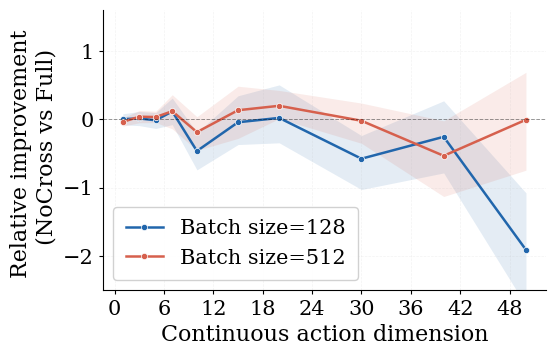


Fetched 258 valid runs.
stores  group_val  disable_cross
8       4          False            11
                   True             11
        8          False            11
                   True             10
16      4          False            11
                   True             11
        8          False            11
                   True             10
24      4          False            11
                   True             11
        8          False            11
                   True             10
32      4          False            11
                   True             11
        8          False            10
                   True             10
40      4          False            11
                   True             11
        8          False            11
                   True             10
48      4          False            11
                   True             11
        8          False            11
                   True             11
Saved 

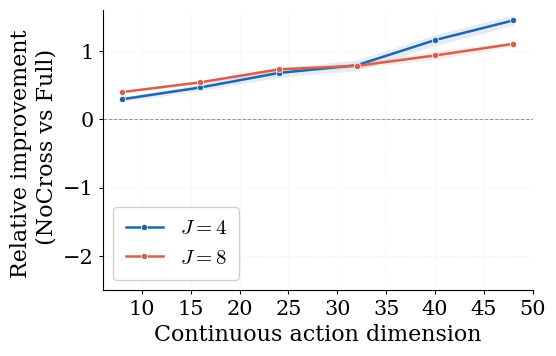

In [9]:
SWEEP_NAMES_INVENTORY_CROSS = ['24o3w7cq', '7rykl1bw']
SWEEP_NAMES_LQR_CROSS = ['cxpb1tj2', '6squair3']
ylimhere = (-2.5, 1.6)

# ── Cross-term comparison: one line per batch_trainer_pair (inventory) ────
stats_ct_btp = plot_cross_term_comparison(
    sweep_names=SWEEP_NAMES_INVENTORY_CROSS,
    wandb_project="inventory_control",
    metric="test/loss/reported",
    x_key="stores",
    group_key="batch_trainer_pair",
    aggregation="mean",
    agent_rename=AGENT_RENAME,
    filters={"batch_trainer_pair": [[128, 200], [512, 800]]},
    group_label_fmt="Batch size={0}",
    xlabel="Continuous action dimension",
    ylabel="Relative improvement \n (NoCross vs Full)",
    out_file="Figures/hpo_cross_term_btp.pdf",
    font_size=16,
    ci_level=0.95,
    ylim=ylimhere,
)

# ── Cross-term comparison: one line per n_modes (switched LQR) ────────────
stats_ct_modes = plot_cross_term_comparison(
    sweep_names=SWEEP_NAMES_LQR_CROSS,
    wandb_project="lqr_switched",
    metric="test/loss/reported",
    x_key="stores",
    group_key="n_modes",
    aggregation="mean",
    ci_level=0.95,
    agent_rename=AGENT_RENAME,
    group_label_fmt="$J={0}$",
    filters={"n_modes": [4, 8]},
    xlabel="Continuous action dimension",
    ylabel="Relative improvement \n (NoCross vs Full)",
    out_file="Figures/hpo_cross_term_modes.pdf",
    font_size=16,
    ylim=ylimhere
)

wandb: Currently logged in as: alvomatias (alvomatias_project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetched 88 runs from sweep xs0iw9x4
Skipping run 3vxdmd9i (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run mi60qvd1 (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run kg55b1eu (hybrid, stores=7): metric 'test/loss/reported' not in summary
Skipping run gcc9ohvf (hybrid, stores=30): metric 'test/loss/reported' not in summary
Skipping run x695iww2 (hybrid, stores=20): metric 'test/loss/reported' not in summary
Skipping run wrj9rosg (hybrid, stores=5): metric 'test/loss/reported' not in summary
Skipping run d1o4nlws (hybrid, stores=10): metric 'test/loss/reported' not in summary
Skipping run an50g0uv (hybrid, stores=7): metric 'test/loss/reported' not in summary
Fetched 88 runs from sweep 8yd4la7p
Skipping run a9jeiddn (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run zuqfibao (gaussian_ppo, stores=1): metric 'test/loss/reported' not in summary
Skipping run yavtefff (gaussian_ppo, stores=7): metric 'test/

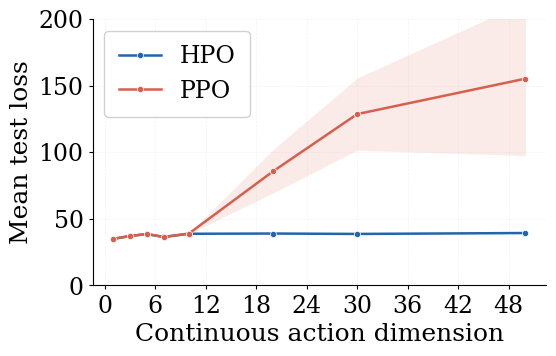

   agent  stores      center       ci_lo       ci_hi   n
0    HPO       1   34.942191   34.922932   34.961450  11
1    HPO       3   37.071001   37.052814   37.089189  11
2    HPO       5   38.569605   38.533413   38.605797  10
3    HPO       7   36.316195   36.272814   36.359575   9
4    HPO      10   38.746833   38.654732   38.838935  10
5    HPO      20   38.928066   38.819726   39.036407  10
6    HPO      30   38.629545   38.412756   38.846335  10
7    HPO      50   39.312127   39.027417   39.596838   9
8    PPO       1   34.919174   34.906316   34.932032   8
9    PPO       3   37.071005   37.060136   37.081875  10
10   PPO       5   38.546130   38.519037   38.573223  10
11   PPO       7   36.425051   36.384849   36.465252   9
12   PPO      10   38.929193   38.687126   39.171260  10
13   PPO      20   85.632744   69.379596  101.885893  10
14   PPO      30  128.561537  101.488458  155.634616  11
15   PPO      50  155.158531   97.442726  212.874335  11


In [7]:

# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------
if __name__ == "__main__":

    stats_abs = plot_agent_comparison(
        sweep_names=SWEEP_NAMES_INVENTORY,
        wandb_project="inventory_control",
        metric="test/loss/reported",
        x_key="stores",
        aggregation="mean",          # "mean" | "median" | "min"
        relative=False,
        agent_rename=AGENT_RENAME,
        xlabel="Continuous action dimension",
        ylabel="Mean test loss",
        title="HPO vs PPO — heterogeneous setting",
        ci_level=0.95,
        out_file="performance_results_jrp.pdf",
        ylim=(0, 200),
        font_size=18,
    )
    print(stats_abs)    


Fetched 426 valid runs across all sweeps.
agent  stores  btp       
HPO    1       (128, 200)    11
               (512, 800)    11
       3       (128, 200)    11
               (512, 800)    11
       5       (128, 200)    11
               (512, 800)    11
       7       (128, 200)    10
               (512, 800)    11
       10      (128, 200)    11
               (512, 800)    11
       15      (128, 200)    11
               (512, 800)    11
       20      (128, 200)    11
               (512, 800)    11
       30      (128, 200)    10
               (512, 800)    11
       40      (128, 200)    11
               (512, 800)    11
       50      (128, 200)    10
               (512, 800)    11
PPO    1       (128, 200)    11
               (512, 800)    10
       3       (128, 200)    10
               (512, 800)    10
       5       (128, 200)    10
               (512, 800)    10
       7       (128, 200)    11
               (512, 800)    10
       10      (128, 200)    10
    

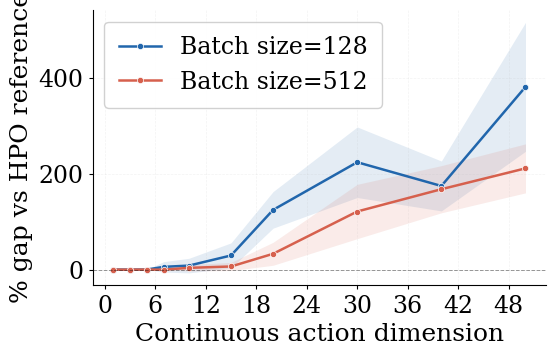

    stores         btp      center       ci_lo       ci_hi   n        ref
0        1  (128, 200)    0.133039    0.074067    0.192012  11  34.901616
1        3  (128, 200)    0.137210    0.061053    0.213366  10  37.019944
2        5  (128, 200)    0.238047    0.186927    0.289167  10  38.448538
3        7  (128, 200)    5.863547   -5.000028   16.727122  11  36.275088
4       10  (128, 200)    8.451508   -6.721891   23.624907  10  38.525900
5       15  (128, 200)   29.521262    3.296950   55.745575  11  37.965732
6       20  (128, 200)  124.420417   86.361387  162.479447  11  38.753695
7       30  (128, 200)  223.661998  150.231017  297.092979  11  38.337444
8       40  (128, 200)  174.227771  122.307019  226.148523  11  38.512803
9       50  (128, 200)  380.537377  246.357211  514.717542  11  38.389364
10       1  (512, 800)    0.058155    0.012434    0.103876  10  34.901616
11       3  (512, 800)    0.048355    0.018202    0.078508  10  37.019944
12       5  (512, 800)    0.174875   -

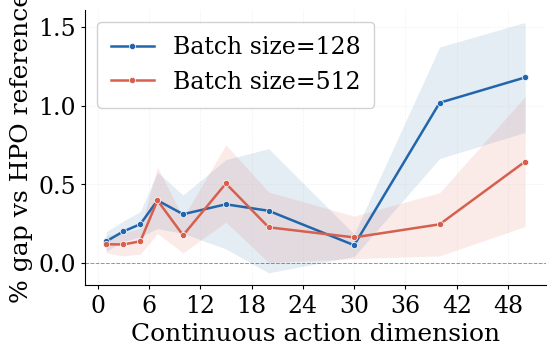

    stores         btp    center     ci_lo     ci_hi   n        ref
0        1  (128, 200)  0.137864  0.076752  0.198976  11  34.901616
1        3  (128, 200)  0.201142  0.135499  0.266785  11  37.019944
2        5  (128, 200)  0.247814  0.167155  0.328473  11  38.448538
3        7  (128, 200)  0.398777  0.219627  0.577927  10  36.275088
4       10  (128, 200)  0.310794  0.188535  0.433053  11  38.525900
5       15  (128, 200)  0.374008  0.090002  0.658013  11  37.965732
6       20  (128, 200)  0.332672 -0.062410  0.727753  11  38.753695
7       30  (128, 200)  0.113739  0.042116  0.185361  10  38.337444
8       40  (128, 200)  1.019912  0.665272  1.374551  11  38.512803
9       50  (128, 200)  1.181047  0.831070  1.531024  10  38.389364
10       1  (512, 800)  0.119974  0.065242  0.174707  11  34.901616
11       3  (512, 800)  0.118317  0.045222  0.191412  11  37.019944
12       5  (512, 800)  0.138673  0.056770  0.220576  11  38.448538
13       7  (512, 800)  0.398796  0.187060  0.61

In [8]:
if __name__ == "__main__":
    SWEEP_NAMES_INVENTORY_BATCH = [
        "24o3w7cq",
        # "7rykl1bw",
        "j641o6qy",
    ]
    batch_filters={"batch_trainer_pair": [[128, 200], [512, 800]]} 
# ── New: PPO lines, one per batch_trainer_pair, vs HPO reference ─────────
    stats_ppo = plot_batch_pair_comparison(
        sweep_names=SWEEP_NAMES_INVENTORY_BATCH,
        wandb_project="inventory_control",
        metric="test/loss/reported",
        x_key="stores",
        agent_filter="PPO",
        reference_agent="HPO",
        batch_trainer_pair_key="batch_trainer_pair",
        top_k_reference=5,              # mean of best 5 HPO runs per x
        aggregation="mean",             # "mean" | "median" | "min"
        ci_level=0.95,                  # set to 0 to suppress CI bands
        agent_rename=AGENT_RENAME,
        btp_label_fmt="Batch size={0}",  # e.g. "B=128, T=200"
        xlabel="Continuous action dimension",
        ylabel="% gap vs HPO reference",
        out_file="ppo_btp_comparison.pdf",
        font_size=18,
        filters=batch_filters,
    )
    print(stats_ppo)

    # ── New: HPO lines, one per batch_trainer_pair, same reference ───────────
    stats_hpo = plot_batch_pair_comparison(
        sweep_names=SWEEP_NAMES_INVENTORY_BATCH,
        wandb_project="inventory_control",
        metric="test/loss/reported",
        x_key="stores",
        agent_filter="HPO",
        reference_agent="HPO",
        batch_trainer_pair_key="batch_trainer_pair",
        top_k_reference=5,
        aggregation="mean",
        ci_level=0.95,
        agent_rename=AGENT_RENAME,
        btp_label_fmt="Batch size={0}",
        xlabel="Continuous action dimension",
        ylabel="% gap vs HPO reference",
        out_file="hpo_btp_comparison.pdf",
        font_size=18,
        filters=batch_filters,
    )
    print(stats_hpo)

### Scaling law

In [21]:
if __name__ == "__main__":

    SWEEP_NAMES_INVENTORY_BATCH = [
        "24o3w7cq",
        # "7rykl1bw",
        "j641o6qy",
    ]
    # ── New: fetch scaling law data once and cache to disk ───────────────────
    CACHE_INV = "scaling_law_cache.parquet"

In [12]:
fetch_data = True
if __name__ == "__main__" and fetch_data:
 
    fetch_scaling_law_data(
        sweep_names=SWEEP_NAMES_INVENTORY_BATCH,
        cache_path=CACHE_INV,
        wandb_project="inventory_control",
        dev_metric="dev/loss/reported",
        x_key="stores",
        batch_trainer_pair_key="batch_trainer_pair",
        agent_rename=AGENT_RENAME,
        # filters={"stores": (None, 40)},  # optional: restrict at fetch time
    )

Fetching history for 330 runs in sweep 24o3w7cq...
  20/330 runs processed...
  40/330 runs processed...
  60/330 runs processed...
  80/330 runs processed...
  100/330 runs processed...
  120/330 runs processed...
  140/330 runs processed...
  160/330 runs processed...
  180/330 runs processed...
  200/330 runs processed...
  220/330 runs processed...
  240/330 runs processed...
  260/330 runs processed...
  280/330 runs processed...
  300/330 runs processed...
  320/330 runs processed...
Fetching history for 330 runs in sweep j641o6qy...
  20/330 runs processed...
  40/330 runs processed...
  60/330 runs processed...
  80/330 runs processed...
  100/330 runs processed...
  120/330 runs processed...
  140/330 runs processed...
  160/330 runs processed...
  180/330 runs processed...
  Skipping run t5qhh1nn: no history for 'dev/loss/reported'
  220/330 runs processed...
  240/330 runs processed...
  260/330 runs processed...
  280/330 runs processed...
  300/330 runs processed...
  Skip

Loaded 657 runs from cache 'scaling_law_cache.parquet'.

Floor and target per group:
  stores=1: floor=34.8899, target=36.6344 (5.0% above floor)
  stores=3: floor=37.0570, target=38.9099 (5.0% above floor)
  stores=5: floor=38.4865, target=40.4109 (5.0% above floor)
  stores=7: floor=36.2761, target=38.0899 (5.0% above floor)
  stores=10: floor=38.5489, target=40.4764 (5.0% above floor)
  stores=15: floor=37.9572, target=39.8551 (5.0% above floor)
  stores=20: floor=38.7509, target=40.6885 (5.0% above floor)
  stores=30: floor=38.3173, target=40.2332 (5.0% above floor)
  stores=40: floor=38.4889, target=40.4133 (5.0% above floor)
  stores=50: floor=38.2617, target=40.1748 (5.0% above floor)

── % of runs reaching target ──────────────────────────────────────
agent  stores  batch_size  n_reached  n_total  pct_reached
  HPO       1         128         11       11   100.000000
  HPO       1         512         11       11   100.000000
  HPO       3         128         11       11   100.0

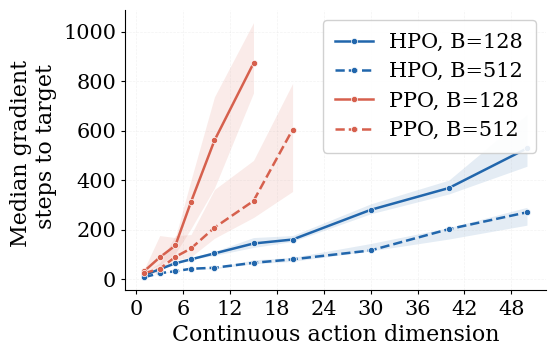

In [22]:
if __name__ == "__main__":
# ── Scaling law: plot from cache (fast) — one line per (agent, batch_size)

    plot_scaling_law(
        cache_path=CACHE_INV,
        reference_agent="HPO",
        x_key="stores",
        group_key="batch_size",               # one line per (agent, batch_size)
        reference_group_keys=None,            # floor per stores only
        top_k_reference=5,
        relative_target=0.05,
        # aggregation="mean",
        aggregation="median",
        impute_non_converged=False,
        ci_level=0.95,
        agents_to_plot=["PPO", "HPO"],
        batch_sizes_to_plot=[128, 512],
        group_label_fmt="B={0}",
        xlabel="Continuous action dimension",
        ylabel="Median gradient \n steps to target",
        out_file="Figures/scaling_jrp.pdf",
        font_size=16,
        max_gradient_steps=1600,
        show_legend=True,
        agent_colors={"HPO": "#2166ac", "PPO": "#d6604d"},  # blue/red per agent
        group_linestyles={128: "-", 512: "--"},               # solid/dashed per batch
    )


## LQR


In [4]:
AGENT_RENAME = {
        "gaussian_ppo": "PPO",
        "hybrid":       "HPO",
    }

CACHE_LQR = "scaling_cache_lqr.parquet"

wandb: Currently logged in as: alvomatias (alvomatias_project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetched 264 runs from sweep cxpb1tj2
Skipping run v4rd9trb (hybrid, stores=24): metric 'test/loss/reported' not in summary
Skipping run 0i2cdaij (hybrid, stores=48): metric 'test/loss/reported' not in summary
Skipping run fg5kw6rr (hybrid, stores=32): metric 'test/loss/reported' not in summary
Fetched 264 runs from sweep 1fbr2bkg
Skipping run vi5pcyy3 (gaussian_ppo, stores=16): metric 'test/loss/reported' not in summary
Skipping run dgx50ud2 (gaussian_ppo, stores=32): metric 'test/loss/reported' not in summary
Skipping run 7foast0g (gaussian_ppo, stores=24): metric 'test/loss/reported' not in summary
Skipping run egchk6qh (gaussian_ppo, stores=32): metric 'test/loss/reported' not in summary
Skipping run hyod8hgx (gaussian_ppo, stores=40): metric 'test/loss/reported' not in summary
Skipping run a7z98cc2 (gaussian_ppo, stores=48): metric 'test/loss/reported' not in summary

Total valid runs: 518
agent  stores  n_modes
HPO    8       2          11
               4          11
            

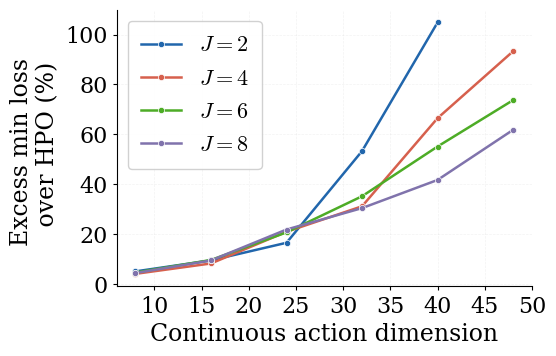

   agent  stores  n_modes      center       ci_lo       ci_hi   n
0    PPO       8        2    5.024740    5.024740    5.024740  11
1    PPO       8        4    4.038844    4.038844    4.038844  11
2    PPO       8        6    4.574873    4.574873    4.574873  11
3    PPO       8        8    4.365010    4.365010    4.365010  11
4    PPO      16        2    9.432435    9.432435    9.432435  11
5    PPO      16        4    8.197932    8.197932    8.197932  11
6    PPO      16        6    9.599090    9.599090    9.599090  10
7    PPO      16        8    9.418761    9.418761    9.418761  11
8    PPO      24        2   16.499665   16.499665   16.499665  11
9    PPO      24        4   20.907693   20.907693   20.907693  11
10   PPO      24        6   20.669711   20.669711   20.669711  11
11   PPO      24        8   21.808745   21.808745   21.808745  10
12   PPO      32        2   53.261484   53.261484   53.261484  11
13   PPO      32        4   31.128888   31.128888   31.128888  11
14   PPO  

In [8]:
if __name__ == "__main__":

# ── LQR experiment: relative gap, one line per n_modes, HPO as baseline ──
    SWEEP_NAMES_LQR = [
        "cxpb1tj2",     # replace with real sweep IDs
        # "6squair3",     # replace with real sweep IDs
        "1fbr2bkg",
    ]

    
    stats_lqr = plot_agent_comparison(
        sweep_names=SWEEP_NAMES_LQR,
        wandb_project="lqr_switched",
        metric="test/loss/reported",
        x_key="stores",
        group_key="n_modes",         # one line per K value
        aggregation="min",          # mean loss; diverged runs inflate this naturally
        relative=True,               # express as % above HPO baseline
        exclude_baseline=True,       # only show PPO lines (HPO is the denominator)
        baseline_agent="HPO",
        agent_rename=AGENT_RENAME,
        exclude_points=[(48, 2)],          # drop stores=40, K=2 (PPO diverged in all seeds)
        group_label_fmt="$J={val}$",       # renders as $J=2$, $J=4$, etc. in legend
        xlabel="Continuous action dimension",
        ylabel="Excess min loss \n over HPO (%)",
        title="PPO vs Hybrid: relative gap grows with continuous action dimension",
        ci_level=0,
        out_file="Figures/performance_results_lqr.pdf",
        font_size=17,
    )
    print(stats_lqr)

In [12]:
fetch_lqr_data = False
if __name__ == "__main__" and fetch_lqr_data:
# ── Scaling law: S-LQR fetch (slow, hits W&B) ────────────────────────────
    # CACHE_LQR = "scaling_cache_lqr.parquet"
 
    fetch_scaling_law_data(
        sweep_names=SWEEP_NAMES_LQR,
        cache_path=CACHE_LQR,
        wandb_project="lqr_switched",
        dev_metric="dev/loss/reported",
        x_key="stores",
        batch_trainer_pair_key=None,          # no btp in LQR
        batch_size_key="batch_size",          # direct batch_size key
        extra_group_keys=["n_modes"],         # store n_modes per run
        agent_rename=AGENT_RENAME,
    )

Fetching history for 264 runs in sweep cxpb1tj2...
  20/264 runs processed...
  40/264 runs processed...
  60/264 runs processed...
  80/264 runs processed...
  100/264 runs processed...
  120/264 runs processed...
  140/264 runs processed...
  160/264 runs processed...
  180/264 runs processed...
  200/264 runs processed...
  220/264 runs processed...
  240/264 runs processed...
  260/264 runs processed...
Fetching history for 264 runs in sweep 1fbr2bkg...
  20/264 runs processed...
  40/264 runs processed...
  60/264 runs processed...
  80/264 runs processed...
  100/264 runs processed...
  120/264 runs processed...
  140/264 runs processed...
  160/264 runs processed...
  180/264 runs processed...
  200/264 runs processed...
  220/264 runs processed...
  240/264 runs processed...
  260/264 runs processed...

Fetched 528 valid runs total.
agent  stores  batch_size  n_modes
HPO    8       128         2          11
                           4          11
                           6  

Loaded 528 runs from cache 'scaling_cache_lqr.parquet'.

Floor and target per group:
  stores=8, n_modes=2: floor=0.3050, target=0.3203 (5.0% above floor)
  stores=8, n_modes=4: floor=0.4955, target=0.5203 (5.0% above floor)
  stores=8, n_modes=6: floor=0.4956, target=0.5204 (5.0% above floor)
  stores=8, n_modes=8: floor=0.5997, target=0.6297 (5.0% above floor)
  stores=16, n_modes=2: floor=0.1592, target=0.1672 (5.0% above floor)
  stores=16, n_modes=4: floor=0.2457, target=0.2580 (5.0% above floor)
  stores=16, n_modes=6: floor=0.2766, target=0.2904 (5.0% above floor)
  stores=16, n_modes=8: floor=0.2869, target=0.3013 (5.0% above floor)
  stores=24, n_modes=2: floor=0.1089, target=0.1143 (5.0% above floor)
  stores=24, n_modes=4: floor=0.1666, target=0.1749 (5.0% above floor)
  stores=24, n_modes=6: floor=0.1872, target=0.1966 (5.0% above floor)
  stores=24, n_modes=8: floor=0.1994, target=0.2093 (5.0% above floor)
  stores=32, n_modes=2: floor=0.0825, target=0.0866 (5.0% above flo

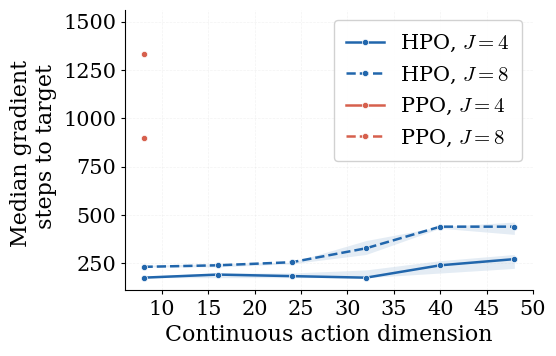

In [ ]:
if __name__ == "__main__":

    # ── Scaling law: S-LQR plot — one line per (agent, n_modes) ──────────────
    plot_scaling_law(
        cache_path=CACHE_LQR,
        reference_agent="HPO",
        x_key="stores",
        group_key="n_modes",                  # one line per (agent, n_modes)
        reference_group_keys=["n_modes"],     # floor per (stores, n_modes)
        top_k_reference=5,
        relative_target=0.5,
        impute_non_converged=False,
        # aggregation="mean",
        aggregation="median",
        ci_level=0.95,
        agents_to_plot=["PPO", "HPO"],
        exclude_groups=[("PPO", 2), ("HPO", 2), ("PPO", 6), ("HPO", 6)],
        group_label_fmt="$J={0}$",
        xlabel="Continuous action dimension",
        ylabel="Median gradient \n steps to target",
        out_file="Figures/scaling_lqr.pdf",
        max_gradient_steps=4000,
        font_size=16,
    )


## Table generation

In [16]:
if __name__ == "__main__":
    SWEEP_NAMES_JRP_TABLE = [
        "24o3w7cq",
        "7rykl1bw",
        "j641o6qy",
    ]
    
    # ── JRP table ──────────────────────────────────────────────────────────────
    jrp_table = generate_latex_table(
    sweep_names=SWEEP_NAMES_JRP_TABLE,
    wandb_project="inventory_control",
    metric="test/loss/reported",
    filters={"batch_trainer_pair": [[128, 200]]},
    # filters={"batch_trainer_pair": [[512, 800]]},
    x_key="stores",
    agent_rename=AGENT_RENAME,
    agents_order=["HPO", "PPO"],          # HPO expands into HPOFull + HPONoCross
    split_agent_by_config={
        "HPO": {"disable_cross_term": ("HPOFull", "HPONoCross")}
    },
    x_label="$J$",
    caption="JRP test loss across product counts. Mean $\\pm$ std and median "
            "over 10 independent trials.",
    label="tab:jrp-results-128",
    float_fmt=".2f",
)
print(jrp_table)

Fetched 330 runs from sweep 24o3w7cq
Skipping run oo6njec1 (hybrid, stores=30): metric 'test/loss/reported' not in summary
Skipping run bw4lk3op (hybrid, stores=7): metric 'test/loss/reported' not in summary
Fetched 330 runs from sweep 7rykl1bw
Fetched 330 runs from sweep j641o6qy
Skipping run 20e5wphr (gaussian_ppo, stores=3): metric 'test/loss/reported' not in summary
Skipping run 53lgdxz3 (gaussian_ppo, stores=5): metric 'test/loss/reported' not in summary
Skipping run tqb89aeb (gaussian_ppo, stores=10): metric 'test/loss/reported' not in summary

Total valid runs: 322
agent  stores
HPO    1         22
       3         22
       5         22
       7         21
       10        21
       15        22
       20        22
       30        21
       40        22
       50        20
PPO    1         11
       3         10
       5         10
       7         11
       10        10
       15        11
       20        11
       30        11
       40        11
       50        11
Fetched

In [17]:
if __name__ == "__main__":

    SWEEP_NAMES_LQR_TABLE = [   
        "cxpb1tj2",
        "6squair3",
        "1fbr2bkg",
    ]
    
    # ── S-LQR table ────────────────────────────────────────────────────────────
    lqr_table = generate_latex_table(
    sweep_names=SWEEP_NAMES_LQR_TABLE,
    wandb_project="lqr_switched",
    metric="test/loss/reported",
    x_key="stores",
    group_key="n_modes",
    agent_rename=AGENT_RENAME,
    agents_order=["HPO", "PPO"],
    split_agent_by_config={
        "HPO": {"disable_cross_term": ("HPOFull", "HPONoCross")}
    },
    x_label="$p$",
    group_key_label="$J$",
    group_label_fmt="$J={val}$",
    loss_multiplier_keys=[
        "stores",
        "setting_config.params_by_dataset.test.periods",
    ],
    caption="S-LQR test loss across action dimensions $p$ and modes $J$. "
            "Mean $\\pm$ std and median over 10 independent trials.",
    label="tab:lqr-results",
    float_fmt=".2f",
)
print(lqr_table)

Fetched 264 runs from sweep cxpb1tj2
Skipping run v4rd9trb (hybrid, stores=24): metric 'test/loss/reported' not in summary
Skipping run 0i2cdaij (hybrid, stores=48): metric 'test/loss/reported' not in summary
Skipping run fg5kw6rr (hybrid, stores=32): metric 'test/loss/reported' not in summary
Fetched 264 runs from sweep 6squair3
Skipping run mnljgr7f (hybrid, stores=40): metric 'test/loss/reported' not in summary
Skipping run bx6guoyw (hybrid, stores=8): metric 'test/loss/reported' not in summary
Skipping run a5sljckx (hybrid, stores=16): metric 'test/loss/reported' not in summary
Skipping run 9zdcnkcn (hybrid, stores=24): metric 'test/loss/reported' not in summary
Skipping run bj39s3y7 (hybrid, stores=32): metric 'test/loss/reported' not in summary
Skipping run y8i8txyj (hybrid, stores=40): metric 'test/loss/reported' not in summary
Fetched 264 runs from sweep 1fbr2bkg
Skipping run vi5pcyy3 (gaussian_ppo, stores=16): metric 'test/loss/reported' not in summary
Skipping run dgx50ud2 (g

Fetched 160 runs from sweep 6dj6kxa3
Fetched 224 runs from sweep uqers37n
Skipping run 689rsro4 (hybrid, stores=5): metric 'test/loss/reported' not in summary
Skipping run az8jm7h6 (hybrid, stores=7): metric 'test/loss/reported' not in summary
Skipping run 19qgi6yi (hybrid, stores=50): metric 'test/loss/reported' not in summary
Skipping run wisfiehh (hybrid, stores=1): metric 'test/loss/reported' not in summary
Skipping run xsaz6282 (hybrid, stores=30): metric 'test/loss/reported' not in summary
Skipping run ege805fh (hybrid, stores=3): metric 'test/loss/reported' not in summary
Skipping run 8naup8at (hybrid, stores=20): metric 'test/loss/reported' not in summary
Skipping run a7tk8e8f (hybrid, stores=5): metric 'test/loss/reported' not in summary
Skipping run kz39rse9 (hybrid, stores=10): metric 'test/loss/reported' not in summary
Skipping run yji6xf7d (hybrid, stores=7): metric 'test/loss/reported' not in summary
Skipping run 7jzy12gq (hybrid, stores=50): metric 'test/loss/reported' n

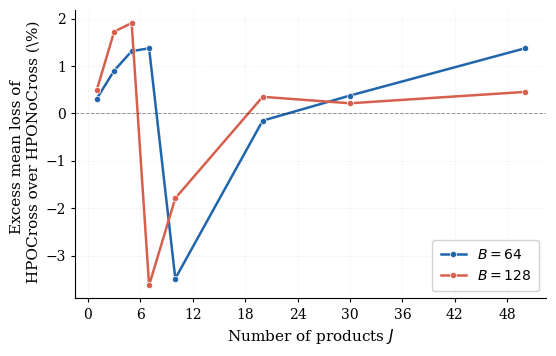

    stores  batch_size       gap     ci_lo     ci_hi
0        1          64  0.309892  0.323649  0.323649
1        3          64  0.901230  0.901230  0.901230
2        5          64  1.312856  1.312856  1.312856
3        7          64  1.373861  1.193943  1.193943
4       10          64 -3.485773 -3.485773 -3.485773
5       20          64 -0.153911 -0.180534 -0.180534
6       30          64  0.376131  0.395298  0.395298
7       50          64  1.371931  1.371931  1.371931
8        1         128  0.486862  0.472868  0.472868
9        3         128  1.723488  1.723488  1.723488
10       5         128  1.907297  1.870244  1.870244
11       7         128 -3.628238 -3.185160 -3.185160
12      10         128 -1.790649 -1.618884 -1.618884
13      20         128  0.349882  0.320006  0.320006
14      30         128  0.213085  0.226735  0.226735
15      50         128  0.452724  0.452724  0.452724


In [ ]:
if __name__ == "__main__":
    # ── Cross term analysis: HPOCross vs HPONoCross, one line per batch_size ──
    SWEEP_NAMES_CROSS = [
        "6dj6kxa3",   # replace with real sweep IDs
        "uqers37n",   # replace with real sweep IDs
    ]
 
    stats_cross = plot_condition_comparison(
        sweep_names=SWEEP_NAMES_CROSS,
        wandb_project="inventory_control",
        metric="test/loss/reported",
        x_key="stores",
        group_key="batch_size",
        condition_key="disable_cross_term",
        condition_baseline=True,    # HPONoCross (no cross term) = denominator
        condition_treatment=False,  # HPOCross (with cross term) = numerator
        agent_rename=AGENT_RENAME,
        aggregation="median",
        group_label_fmt="$B={val}$",
        xlabel="Number of products $J$",
        ylabel="Excess mean loss of \n HPOCross over HPONoCross (\\%)",
        ci_level=0,
        out_file="cross_term_analysis.pdf",
    )
    print(stats_cross)

### Boundary steepness

In [10]:
import numpy as np
from pathlib import Path
import pandas as pd

# Pick latest aggregate dump file
files = sorted(Path("artifacts/inventory_action_plot_data/hybrid_cos_sim").glob("inventory_action_all_epochs_ts_*.npz"))
assert files, "No aggregate dump file found."
dump_path = files[-1]

with np.load(dump_path) as data:
    inventory_by_epoch = data["inventory_sum_by_epoch"]          # [E, P]
    action_by_epoch = data["total_action_by_epoch"]              # [E, P]
    discrete_by_epoch = data["discrete_actions_by_epoch"]        # [E, P] (may be NaN)
    epoch_by_row = data["epoch_by_row"]                          # [E]
    num_points_by_epoch = data["num_points_by_epoch"]            # [E]
    dev_loss_by_epoch = data["dev_loss_reported_by_epoch"]       # [E]
    normalized_flag = data["normalize_by_mean_demand_by_epoch"]  # [E]

In [11]:
rows = []
for i in range(len(epoch_by_row)):
    n = int(num_points_by_epoch[i])  # valid points before NaN padding
    rows.append(pd.DataFrame({
        "epoch": int(epoch_by_row[i]),
        "inventory_sum": inventory_by_epoch[i, :n],
        "total_action": action_by_epoch[i, :n],
        "discrete_action": discrete_by_epoch[i, :n],
        "dev_loss_reported": float(dev_loss_by_epoch[i]),
        "normalized": bool(normalized_flag[i]),
    }))

df = pd.concat(rows, ignore_index=True)
df.head()

,epoch,inventory_sum,total_action,discrete_action,dev_loss_reported,normalized
0,0,0.0,-1.182132e-06,0.0,3362.725098,False
1,0,0.0,-1.388034e-06,0.0,3362.725098,False
2,0,0.0,-1.906737e-06,0.0,3362.725098,False
3,0,0.0,-1.215791e-06,0.0,3362.725098,False
4,0,0.0,-9.525684e-07,0.0,3362.725098,False


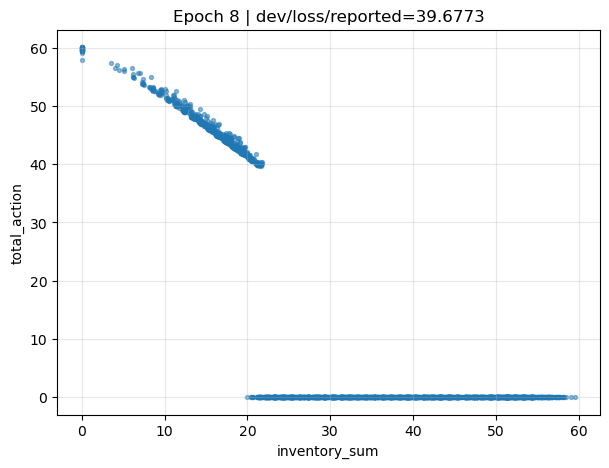

In [ ]:
import matplotlib.pyplot as plt

# One epoch
e = df["epoch"].max()
dfe = df[df["epoch"] == e]
plt.figure(figsize=(7,5))
plt.scatter(dfe["inventory_sum"], dfe["total_action"], s=8, alpha=0.5)
plt.title(f"Epoch {e} | dev/loss/reported={dfe['dev_loss_reported'].iloc[0]:.4f}")
plt.xlabel("inventory_sum")
plt.ylabel("total_action")
plt.grid(alpha=0.3)
plt.show()

In [79]:
import numpy as np
from pathlib import Path
import pandas as pd


def load_action0_run(run_name: str, exp_name: str = "hybrid_cos_sim"):
    """Load one run folder of per-epoch action0-prob dumps."""
    run_dir = Path("artifacts/inventory_discrete_action0_prob_plot_data") / exp_name / run_name
    files = sorted(run_dir.glob("inventory_discrete_action0_prob_epoch_*_ts_*.npz"))
    assert files, f"No action0-prob dump files found in {run_dir}"
    return files

import matplotlib.pyplot as plt


def plot_inventory_vs_action0_prob(
    df: "pd.DataFrame",
    epoch: int | None = None,
    x_label: str = "inventory_sum",
    y_label: str = "prob(action=0)",
    dot_size: float = 8,
    subset: int | float | None = None,
    font_size: int = 16,
    random_state: int = 0,
    log_y: bool = False,
    log_eps: float = 1e-12,
    save_plot: bool = False,
    save_dir: str = "Figures",
    filename_prefix: str = "inventory_vs_action0_prob",
):
    """
    Styled like scaling-law plots, without legend.

    subset:
      - None: use all points
      - int > 0: sample that many points (without replacement)
      - float in (0, 1]: sample that fraction of points

    log_y:
      - False: plot probability directly
      - True: plot log(probability), using clipping at log_eps for stability
    """
    if epoch is None:
        epoch = int(df["epoch"].max())
    dev_loss = float(df[df["epoch"] == epoch]["dev_loss_reported"].iloc[0])
    print(dev_loss)

    dfe = df[df["epoch"] == epoch].copy()
    if dfe.empty:
        raise ValueError(f"No rows found for epoch={epoch}.")

    # Optional subsampling for speed/clarity
    n = len(dfe)
    if subset is not None:
        if isinstance(subset, float):
            if not (0 < subset <= 1):
                raise ValueError("When subset is float, it must be in (0, 1].")
            n_keep = max(1, int(round(n * subset)))
        else:
            n_keep = int(subset)
            if n_keep <= 0:
                raise ValueError("When subset is int, it must be > 0.")
        if n_keep < n:
            dfe = dfe.sample(n=n_keep, random_state=random_state)

    # Match notebook aesthetic/font from scaling-law plots
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 1,
        "ytick.labelsize": font_size - 1,
        "axes.titlesize": font_size + 1,
    })

    # Optional log transform of probability values.
    if log_y:
        y_values = np.log(np.clip(dfe["action0_prob"].to_numpy(), log_eps, 1.0))
    else:
        y_values = dfe["action0_prob"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        dfe["inventory_sum"],
        y_values,
        s=dot_size,
        alpha=0.55,
        color="#1f77b4",
    )

    ax.set_xlabel(x_label)
    if y_label == "prob(action=0)" and log_y:
        ax.set_ylabel("log(prob(action=0))")
    else:
        ax.set_ylabel(y_label)
    if not log_y:
        ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    plt.tight_layout()

    if save_plot:
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        out_file = save_path / f"{filename_prefix}_epoch_{epoch:04d}_devloss{dev_loss}.pdf"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {out_file}")

    plt.show()

In [80]:
# Set the run folder you want to analyze
run_name = "run_1777469737"  # change me
# run_name = "run_1765171080"  # change me
files = load_action0_run(run_name=run_name, exp_name="hybrid_cos_sim")

rows = []
for fp in files:
    with np.load(fp) as data:
        inventory = data["inventory_sum"]          # [N]
        action0_prob = data["action0_prob"]        # [N]
        epoch = int(data["epoch"][0])              # scalar wrapped in array

        if "dev_loss_reported" in data:
            dev_loss = float(data["dev_loss_reported"][0])
        else:
            dev_loss = np.nan

        if "normalize_by_mean_demand" in data:
            normalized = bool(data["normalize_by_mean_demand"][0])
        else:
            normalized = False

        rows.append(pd.DataFrame({
            "run_name": run_name,
            "epoch": epoch,
            "inventory_sum": inventory,
            "action0_prob": action0_prob,
            "dev_loss_reported": dev_loss,
            "normalized": normalized,
            "source_file": fp.name,
        }))

df_action0 = pd.concat(rows, ignore_index=True).sort_values(["run_name", "epoch"]).reset_index(drop=True)
df_action0.head()

,run_name,epoch,inventory_sum,action0_prob,dev_loss_reported,normalized,source_file
0,run_1777469737,0,0.0,0.504940,141.872829,False,inventory_discrete_action0_prob_epoch_0000_ts_...
1,run_1777469737,0,0.0,0.513548,141.872829,False,inventory_discrete_action0_prob_epoch_0000_ts_...
2,run_1777469737,0,0.0,0.501158,141.872829,False,inventory_discrete_action0_prob_epoch_0000_ts_...
3,run_1777469737,0,0.0,0.515430,141.872829,False,inventory_discrete_action0_prob_epoch_0000_ts_...
4,run_1777469737,0,0.0,0.512247,141.872829,False,inventory_discrete_action0_prob_epoch_0000_ts_...


40.29692804245722


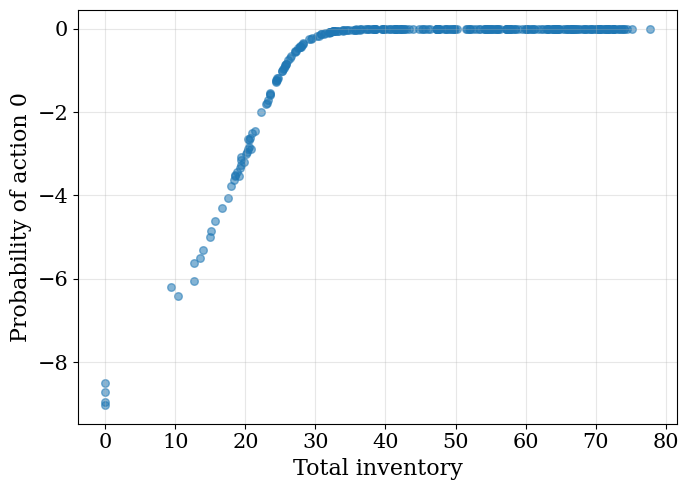

In [97]:
# Example call
plot_inventory_vs_action0_prob(
    df_action0,
    epoch=114,                 # latest epoch
    # epoch=129,                 # latest epoch
    # epoch=None,                 # latest epoch
    x_label="Total inventory",
    y_label="Probability of action 0",
    dot_size=30,
    subset=0.1,                 # e.g. 50% of dots; set None for all
    font_size=16,
    save_plot=False,
    save_dir="Figures/inventory_vs_action0_prob",
    filename_prefix="logprobs_",
    log_y=True,
)
